# **5.9 회귀 실습 - 자전거 대여 수요 예측**

https://www.kaggle.com/competitions/bike-sharing-demand/data 에서 `train.csv` 파일 다운로드 후, `bike-train.csv`로 파일명 변경

➡️ 2011~2012 날짜/시간, 기온, 습도, 풍속 등의 정보를 기반으로 1시간 간격 동안의 자전거 대여 횟수가 기재되어있음 

- datetime: hourly date + time stamp
- season : 1=봄, 2=여름, 3=가을, 4겨울
- holiday : 1=토,일 주말을 제외한 휴일, 0=휴일이 아닌날
- workingday : 1=주말 및 휴일이 아닌 주중, 0=주밀 및 휴일
- weather: 1,2,3,4 4로 갈 수록 심한 눈/비, 천둥/번개
- temp : 온도 (섭씨)
- atemp : 체감 온도 (섭씨)
- humidity : 상대습도
- windspeed : 풍속
- casual : 사전에 등록 안한 사용자가 대여한 횟수
- registered : 사전 등록 사용자가 대여한 횟수
- count : 대여 횟수

✅ **데이터 클렌징 및 가공과 데이터 시각화**



- 데이터 로드 및 확인

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

bike_df = pd.read_csv('./bike_train.csv')
print(bike_df.shape)
bike_df.head()

(10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


➡️ 10886개의 레코드와 12개 칼럼으로 구성

In [16]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


➡️ datetime칼럼의 경우 가공이 필요

- datetime 문자열을 datetime 형식으로 변환
  

In [25]:
# 문자열을 datetime으로 변경
bike_df['datetime'] = bike_df.datetime.apply(pd.to_datetime)

# datetime 타입에서 년, 월, 일, 시간 추출
bike_df['year'] = bike_df.datetime.apply(lambda x : x.year)
bike_df['month'] = bike_df.datetime.apply(lambda x : x.month)
bike_df['day'] = bike_df.datetime.apply(lambda x : x.day)
bike_df['hour'] = bike_df.datetime.apply(lambda x : x.hour)
bike_df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2


➡️ casual + registered = count 이므로 두 칼럼 / date time 칼럼 삭제하기

In [30]:
drop_columns = ['datetime', 'casual', 'registered']
bike_df.drop(drop_columns, axis=1, inplace=True)

- 주요 칼럼별 count의 분포 시각화

seaborn의 barplot 활용

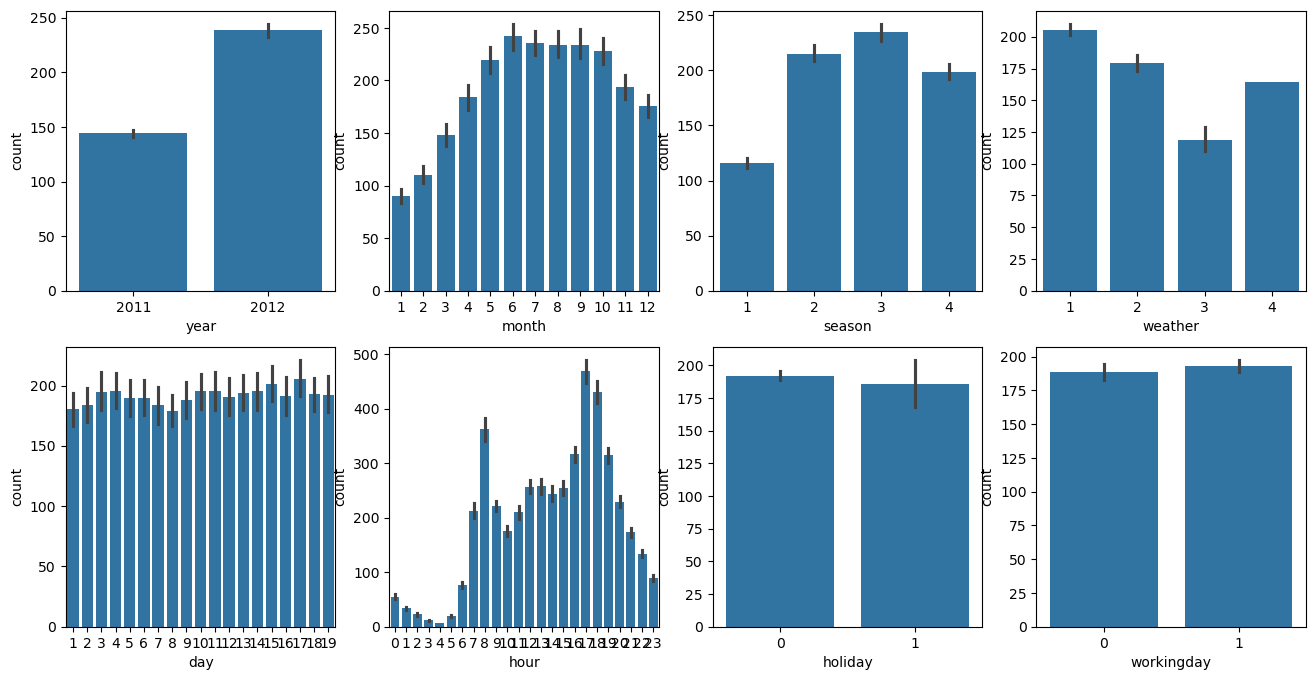

In [37]:
fig, axs = plt.subplots(figsize=(16,8), ncols=4, nrows=2)
cat_features = ['year', 'month', 'season', 'weather', 'day', 'hour', 'holiday', 'workingday']
# cat_features에 있는 모든 칼럼별로 개별 칼럼값에 따른 count의 합을 barplot으로 시각화
for i, feature in enumerate(cat_features):
    row = int(i/4)
    col = i%4
    # seaborn의 barplot을 이요앻 칼럼값에 따른 count의 합을 표현
    sns.barplot(x=feature, y='count', data=bike_df, ax=axs[row][col])

➡️ 2012년이 상대적으로 값이 높음 = 시간이 지날수록 자전거 대여 횟수가 지속적으로 증가한 결과라고 여길 수 있음
<br>
➡️ month의 경우 6789ndjfdl , 계절의 경우 여름과 가을에, weather의 경우 맑거나(1) 약간 안개가 있는경우 (2)가 높다
<br>
➡️ hour의 경우는 오전출근시간 (8)과 오후 퇴근시간 (17,18)이 상대적으로 높다. day간 차이는 크지 않으며, holiday또는 workingday는 주중일 경우가 상대적으로 높다.

- 다양한 회귀 모델을 적용해 예측 성능 측정

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# log 값 변환 시 NaN 등의 이슈로 log()가 아닌 log1p()를 이용해 RMSLE계산
def rmsle(y, pred):
    log_y = np.log1p(y)
    log_pred = np.log1p(pred)
    squared_error = (log_y - log_pred)**2
    rmsle = np.sqrt(np.mean(squared_error))
    return rmsle

# 사이킷런의 mean_square_error()를 이용해 RMSE 계산
def rmse(y, pred):
    return np.sqrt(mean_squared_error(y, pred))

# MAE, RMSE, RMSLE를 모두 계산
def evaluate_regr(y, pred):
    rmsle_val = rmsle(y, pred)
    rmse_val = rmse(y, pred)
    # MAE는 사이킷런의 mean_absoluate_error()로 계산
    mae_val = mean_absolute_error(y,pred)
    print('RMSLE: {0:.3f}, RMSE: {1:.3f}, MAE: {2:.3f}'.format(rmsle_val, rmse_val, mae_val))

➡️ `log1p(x)`의 경우, log(1+x)로 변환되므로, x값이 0이 되더라도 무한대가 되지 않고 0이되므로 오버플로/언더플로 문제를 해결가능 

### **✅ 로그 변환, 피처 인코딩과 모델 학습/예측/평가**

- LinearRegression 객체를 이용해 회귀 예측 

In [51]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso

y_target = bike_df['count']
X_features = bike_df.drop(['count'], axis =1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.3, random_state=0)

lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
pred = lr_reg.predict(X_test)

evaluate_regr(y_test, pred)

RMSLE: 1.165, RMSE: 140.900, MAE: 105.924


➡️ 비교적 큰값, 오류 값 큰 순으로 5개 확인해보자

In [58]:
def get_top_error_data(y_test, pred, n_tops = 5):
    # DataFrame 칼럼으로 실제 대여 횟수와 예측값을 서로 비교할 수 있도록 생성
    result_df = pd.DataFrame(y_test.values, columns=['real_count'])
    result_df['predicted_count'] = np.round(pred)
    result_df['diff'] = np.abs(result_df['real_count'] - result_df['predicted_count'])

    # 예측값과 실제 값이 가장 큰 데이터 순으로 출력
    print(result_df.sort_values('diff',ascending=False)[:n_tops])

get_top_error_data(y_test, pred, n_tops=5)

      real_count  predicted_count   diff
1618         890            322.0  568.0
3151         798            241.0  557.0
966          884            327.0  557.0
412          745            194.0  551.0
2817         856            310.0  546.0


➡️ 큰 예측 오류 발생의 경우, 타겟값 분포 살펴보기

<Axes: >

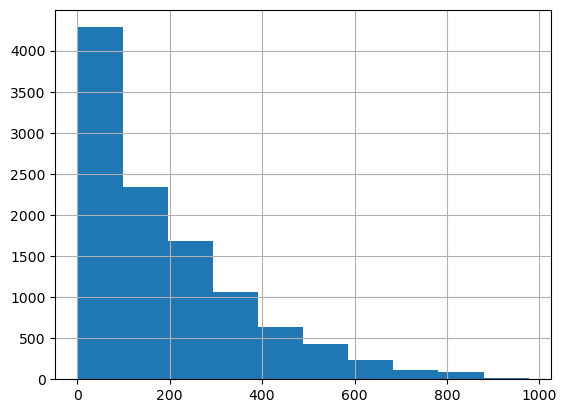

In [61]:
y_target.hist()

➡️ 왜곡된 분포이므로 정규분포로 바꾸기 위해, log1p()를 적용하기

<Axes: >

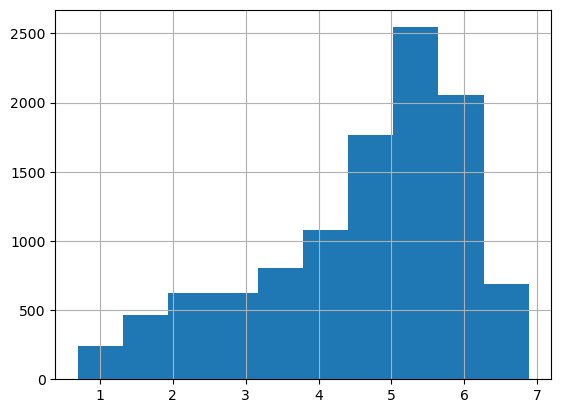

In [66]:
y_log_transform = np.log1p(y_target)
y_log_transform.hist()

➡️ 왜곡정도가 향상됨

In [73]:
# 타깃 칼럼인 count 값을 log1p로 로그 변환
y_target_log = np.log1p(y_target)

# 로그 변환된 y_target_log를 반영해 학습/테스트 데이터 세트 분할
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target_log, test_size=0.3, random_state=0)

lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
pred=lr_reg.predict(X_test)

# 테스트 데이터 세트의 Target값은 로그 변환됐으므로 다시 expm1을 이용해 원래 스케일로 변환
y_test_exp = np.expm1(y_test)

# 예측값 역시 로그 변환된 타깃 기반으로 학습돼 예측됐으므로 다시 expm1로 스케일 변환
pred_exp = np.expm1(pred)

evaluate_regr(y_test_exp, pred_exp)

RMSLE: 1.017, RMSE: 162.594, MAE: 109.286


➡️ RMSLE 오류는 줄어들었지만, RMSE는 오히려 늘어남. 개별 피처 인코딩 적용해보기


<Axes: ylabel='None'>

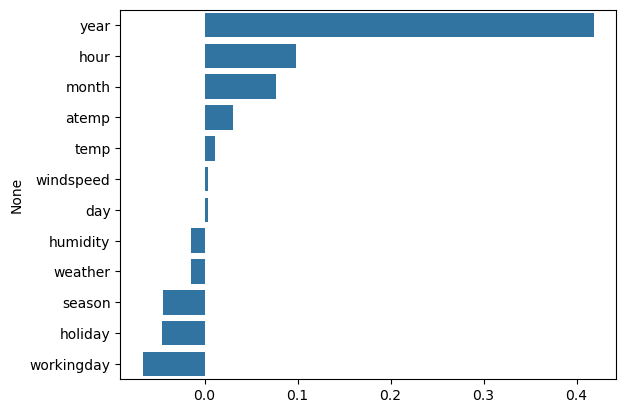

In [77]:
coef = pd.Series(lr_reg.coef_, index=X_features.columns)
coef_sort = coef.sort_values(ascending=False)
sns.barplot(x=coef_sort.values, y=coef_sort.index)

➡️ 카테고리형 변수들에 대한 원핫인코딩 적용 필요

In [80]:
# year, month, day, hour 등의 피처들을 One-Hot Encoding
X_features_ohe = pd.get_dummies(X_features, columns = ['year', 'month','day','hour','holiday','workingday','season','weather'])

- 사이킷런 선형 회귀 모델로 모두 학습해 예측성능 확인

In [85]:
# 원-핫 인코딩이 적용된 피처 데이터 세트 기반으로 학습/예측 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_features_ohe, y_target_log, test_size=0.3, random_state=0)

# 모델과 학습/테스트 데이터 세트를 입력하면 평가 수치를 변환
def get_model_predict(model, X_train, X_test, y_train, y_test, is_expm1=False):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    if is_expm1:
        y_test = np.expm1(y_test)
        pred = np.expm1(pred)
    print("###", model.__class__.__name__,"###")
    evaluate_regr(y_test,pred)
# end of function get_model_predict

# 모델별로 평가 수행
lr_reg = LinearRegression()
ridge_reg = Ridge(alpha=10)
lasso_reg = Lasso(alpha=0.01)

for model in [lr_reg, ridge_reg, lasso_reg] :
    get_model_predict(model, X_train, X_test, y_train, y_test, is_expm1=True)

### LinearRegression ###
RMSLE: 0.590, RMSE: 97.690, MAE: 63.383
### Ridge ###
RMSLE: 0.590, RMSE: 98.529, MAE: 63.893
### Lasso ###
RMSLE: 0.635, RMSE: 113.219, MAE: 72.803


➡️ 예측 성능이 많이 향상됨 

<Axes: ylabel='None'>

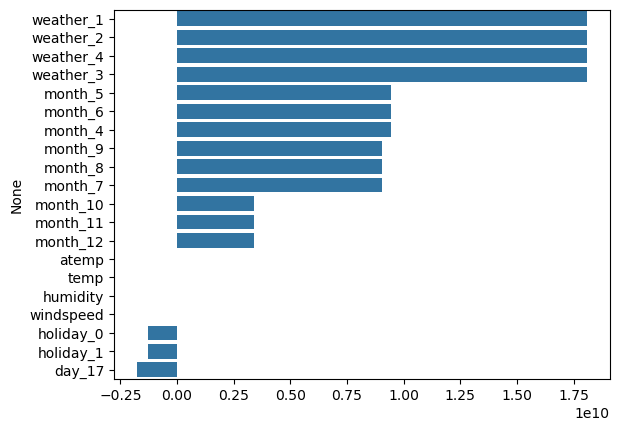

In [88]:
coef = pd.Series(lr_reg.coef_ , index=X_features_ohe.columns)
coef_sort = coef.sort_values(ascending=False)[:20]
sns.barplot(x=coef_sort.values, y=coef_sort.index)

➡️ year관련 피처들의 회귀계수 값이 가장 높지만, season,weather관련 속성들의 회귀계수 값도 상대적으로 커짐 

- 회귀 트리 사용하기

In [96]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 랜덤 포래스트, GBM, XGBoost, LightGBM 모델 별로 평가 수행
rf_reg = RandomForestRegressor(n_estimators=500)
gbm_reg = GradientBoostingRegressor(n_estimators=500)
xgb_reg = XGBRegressor(n_estimators=500)
lgbm_reg = LGBMRegressor(n_estimators=500)

for model in [rf_reg, gbm_reg, xgb_reg, lgbm_reg]:
    # XGBoost의 경우 DataFrame이 입력될 경우 버전에 따라 오류 발생 가능, ndarray로 변환
    get_model_predict(model, X_train.values, X_test.values, y_train.values, y_test.values, is_expm1=True)

### RandomForestRegressor ###
RMSLE: 0.355, RMSE: 50.381, MAE: 31.173
### GradientBoostingRegressor ###
RMSLE: 0.330, RMSE: 53.339, MAE: 32.746
### XGBRegressor ###
RMSLE: 0.339, RMSE: 51.475, MAE: 31.357
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002834 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 348
[LightGBM] [Info] Number of data points in the train set: 7620, number of used features: 72
[LightGBM] [Info] Start training from score 4.582043
### LGBMRegressor ###
RMSLE: 0.319, RMSE: 47.215, MAE: 29.029


➡️ 성능이 개선됨, 하지만 데이터세트에 유형에 따라 달라질 수도 있음 

# **5.10 회귀 실습 - 캐글 주택 가격: 고급 회귀 기법** 

https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data?select=train.csv 에서 train.csv 다운 받은 후, house_prices.csv로 저장

**✅ 데이터 사전 처리(Preprocessing)**

In [174]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

house_df_org = pd.read_csv('house_price.csv')
house_df = house_df_org.copy()
house_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [176]:
print('데이터 세트의 Shape:', house_df.shape)
print('\n전체 피처의 type\n', house_df.dtypes.value_counts())
isnull_series = house_df.isnull().sum()
print('\nNull 칼럼과 그 건수:\n', isnull_series[isnull_series>0].sort_values(ascending=False))

데이터 세트의 Shape: (1460, 81)

전체 피처의 type
 object     43
int64      35
float64     3
Name: count, dtype: int64

Null 칼럼과 그 건수:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


➡️ Null값이 너무 많은 피처는 드롭하기

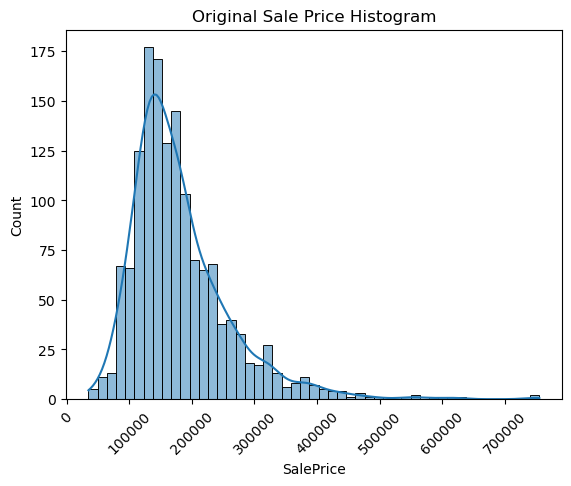

In [179]:
plt.title('Original Sale Price Histogram')
plt.xticks(rotation=45)
sns.histplot(house_df['SalePrice'], kde=True)
plt.show()

➡️ 로그변환 적용하기 (로그변환한 값을 기반으로 학습한 뒤, 예측 후에는 다시 `expm1()`으로 환원하기)

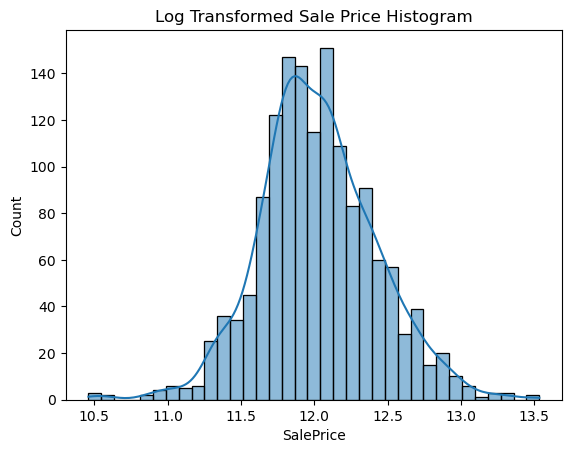

In [181]:
plt.title('Log Transformed Sale Price Histogram')
log_SalePrice = np.log1p(house_df['SalePrice'])
sns.histplot(log_SalePrice, kde=True)
plt.show()

➡️ 정규분포형태의 결과값 확인 가능 

In [184]:
# SalePrice 로그 변환
original_SalePrice = house_df['SalePrice']
house_df['SalePrice'] = np.log1p(house_df['SalePrice'])

# 불필요한 열 삭제
house_df.drop(['Id', 'PoolQC','MiscFeature', 'Alley', 'Fence', 'FireplaceQu'], axis=1, inplace=True)

# 숫자형 열만 평균으로 채우기
numeric_cols = house_df.select_dtypes(include=[np.number]).columns
house_df[numeric_cols] = house_df[numeric_cols].fillna(house_df[numeric_cols].mean())

In [186]:
# Null 값이 있는 피처명과 추출
house_df.isnull().sum()[house_df.isnull().sum()!=0]

MasVnrType      872
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
GarageType       81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64

➡️ 문자형 피처를 제외하고는 Null값이 없음<br>
➡️ 원핫인코딩에선 Null은 0으로 변환됨 

In [190]:
print('get_dummies() 수행 전 데이터 Shape:', house_df.shape)
house_df_ohe = pd.get_dummies(house_df)
print('get_dummies() 수행 후 데이터 Shape:', house_df_ohe.shape)

null_column_count = house_df_ohe.isnull().sum()[house_df_ohe.isnull().sum() > 0]
print('## Null 피처의 Type:\n', house_df_ohe.dtypes[null_column_count.index])

get_dummies() 수행 전 데이터 Shape: (1460, 75)
get_dummies() 수행 후 데이터 Shape: (1460, 270)
## Null 피처의 Type:
 Series([], dtype: object)


➡️ 피처가 증가했다

**✅ 선형 회귀 모델 학습/예측/평가**

현재 실제 값과 예측값이 로그 변환 값이므로 RMSE만 적용하면 자동으로 RMSLE가 측정됨 

In [194]:
def get_rmse(model):
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    rmse=np.sqrt(mse)
    print(model.__class__.__name__, ' 로그 변환된 RMSE:', np.round(rmse, 3))
    return rmse

def get_rmses(models):
    rmses = []
    for model in models:
        rmse = get_rmse(model)
        rmses.append(rmse)
    return rmses

In [196]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1, inplace=False)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=156)

# LinearRegression, Ridge, Lasso 학습, 예측, 평가
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
ridge_reg = Ridge()
ridge_reg.fit(X_train, y_train)
lasso_reg = Lasso()
lasso_reg.fit(X_train, y_train)

models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models)

LinearRegression  로그 변환된 RMSE: 0.132
Ridge  로그 변환된 RMSE: 0.127
Lasso  로그 변환된 RMSE: 0.176


[0.1318318468825032, 0.1274058283626614, 0.17628250556471403]

➡️ 라쏘 회귀의 경우 회귀 성능이 떨어짐, 하이퍼 파라미터 튜닝 필요
<br>

- 피쳐별 회귀 계수 시각화 

In [200]:
def get_top_bottom_coef(model, n=10):
    # coef_ 속성을 기반으로 Series 객체를 생성. index는 칼럼명
    coef = pd.Series(model.coef_, index=X_features.columns)

    # + 상위 10개, - 하위 10개의 회귀 계수를 추출해 반환
    coef_high = coef.sort_values(ascending=False).head(n)
    coef_low = coef.sort_values(ascending=False).tail(n)
    return coef_high, coef_low

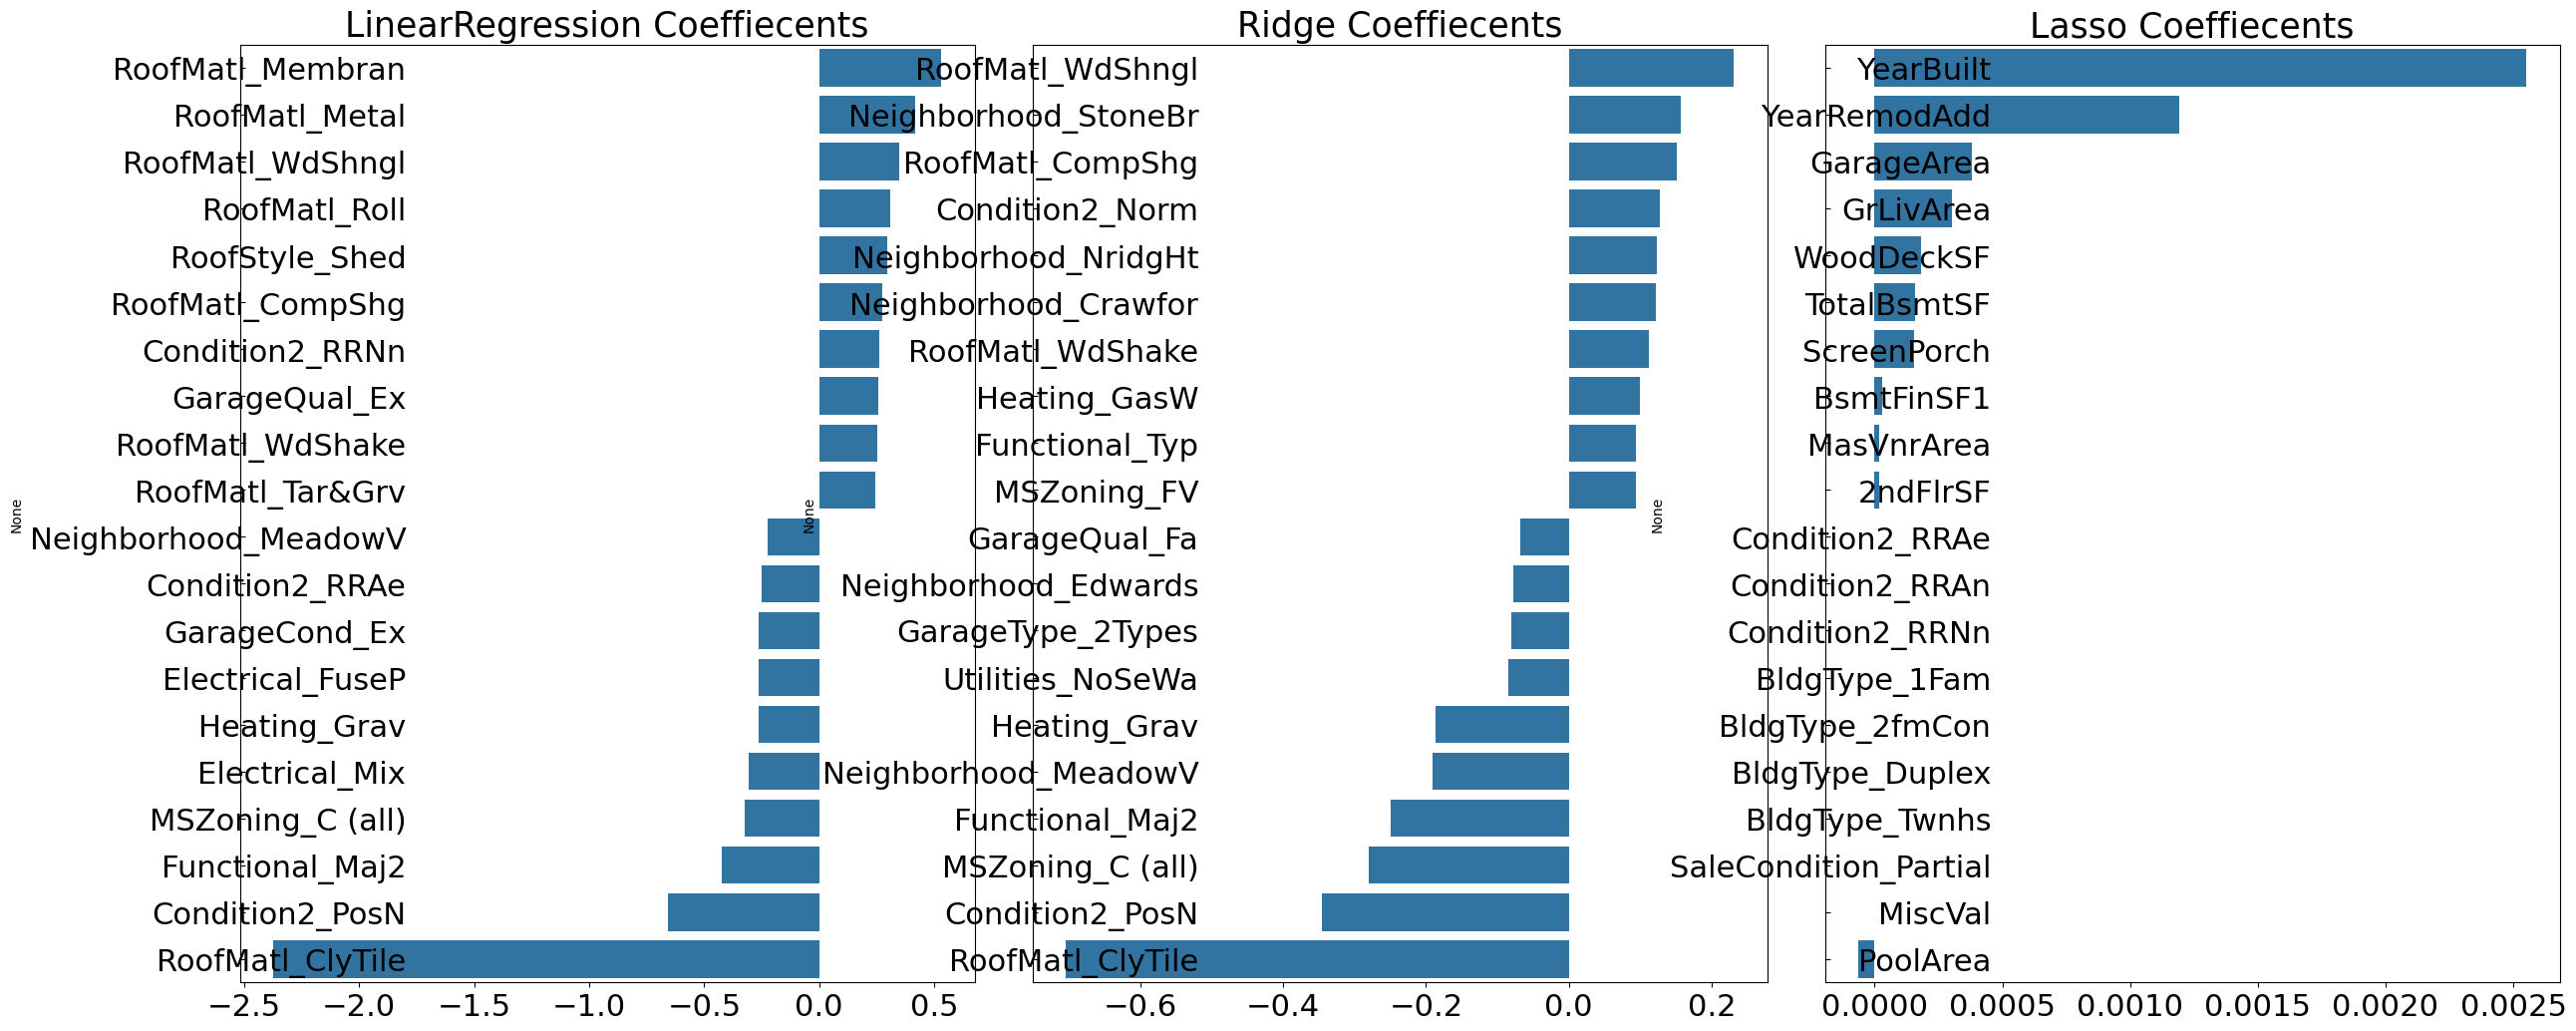

In [202]:
def visualize_coefficient(models):
    # 3개 회귀 모델의 시각화를 위해 3개의 칼럼을 가지는 subplot생성 
    fig, axs = plt.subplots(figsize=(24,10), nrows=1, ncols=3)
    fig.tight_layout()
    # 입력 인자로 받은 list 객체인 models에서 차례로 model을 추출해 회귀 계수 시각화
    for i_num, model in enumerate(models):
        # 상위 10개, 하위 10개 회귀계수를 구해고, 이를 판다스 concat으로 결합
        coef_high, coef_low = get_top_bottom_coef(model)
        coef_concat = pd.concat([coef_high, coef_low])
        # ax subplot에 barchar로 표현. 한 화면에 표현하기 위해 tick label 위치와 font 크기 조정
        axs[i_num].set_title(model.__class__.__name__+' Coeffiecents', size=25)
        axs[i_num].tick_params(axis="y", direction="in", pad=-120)
        for label in (axs[i_num].get_xticklabels() + axs[i_num].get_yticklabels()):
            label.set_fontsize(22)
        sns.barplot(x=coef_concat.values, y=coef_concat.index, ax=axs[i_num])

# 앞 예제에서 학습한 lr_reg, ridge_reg, lasso_reg 모델의 회귀 계수 시각화
models = [lr_reg, ridge_reg, lasso_reg]
visualize_coefficient(models)

➡️ Lasso는 전체적으로 회귀 계수 값이 매우 작고 다른 형태를 띄고 있음 
<br>
➡️ 데이터 세트를 분할하지 않고 폴드로 분할 검증하기 

In [204]:
from sklearn.model_selection import cross_val_score

def get_avg_rmse_cv(models):

    for model in models:
        # 분할하지 않고 전체 데이터로 cross_val_score() 수행. 모델별 CV RMSE값과 평균 RMSE 출력
        rmse_list = np.sqrt(-cross_val_score(model, X_features, y_target, scoring="neg_mean_squared_error", cv=5))

        rmse_avg = np.mean(rmse_list)
        print('\n{0} CV RMSE 값 리스트 : {1}'.format(model.__class__.__name__, np.round(rmse_list, 3)))
        print('{0} CV 평균 RMSE 값 : {1}'.format(model.__class__.__name__,np.round(rmse_avg, 3)))

# 앞 예제에서 학습한 ridge_reg, lasso_reg 모델의 CV RMSE값 출력
model = [ridge_reg, lasso_reg]
get_avg_rmse_cv(models)


LinearRegression CV RMSE 값 리스트 : [0.135 0.165 0.167 0.111 0.198]
LinearRegression CV 평균 RMSE 값 : 0.155

Ridge CV RMSE 값 리스트 : [0.117 0.154 0.142 0.117 0.189]
Ridge CV 평균 RMSE 값 : 0.144

Lasso CV RMSE 값 리스트 : [0.161 0.204 0.177 0.181 0.265]
Lasso CV 평균 RMSE 값 : 0.198


➡️ 여전히 라쏘의 성능이 떨어짐<br>
➡️ 하이퍼 파라미터 최적화 해보자

In [206]:
from sklearn.model_selection import GridSearchCV

def print_best_params(model, params):
    grid_model = GridSearchCV(model, param_grid=params, scoring='neg_mean_squared_error', cv=5)
    grid_model.fit(X_features, y_target)
    rmse = np.sqrt(-1*grid_model.best_score_)
    print('{0} 5 CV 시 최적 평균 RMSE 값:{1}, 최적 alpha:{2}'.format(model.__class__.__name__, np.round(rmse, 4), grid_model.best_params_))

ridge_params = {'alpha': [0.05, 0.1, 1, 5, 8, 10, 12, 15, 20]}
lasso_params = {'alpha': [0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1, 5, 10]}
print_best_params(ridge_reg, ridge_params)
print_best_params(lasso_reg, lasso_params)

Ridge 5 CV 시 최적 평균 RMSE 값:0.1418, 최적 alpha:{'alpha': 12}
Lasso 5 CV 시 최적 평균 RMSE 값:0.142, 최적 alpha:{'alpha': 0.001}


➡️ 라쏘의 경우 최적화 이후 예측 성능이 많이 좋아짐 

LinearRegression  로그 변환된 RMSE: 0.132
Ridge  로그 변환된 RMSE: 0.124
Lasso  로그 변환된 RMSE: 0.12


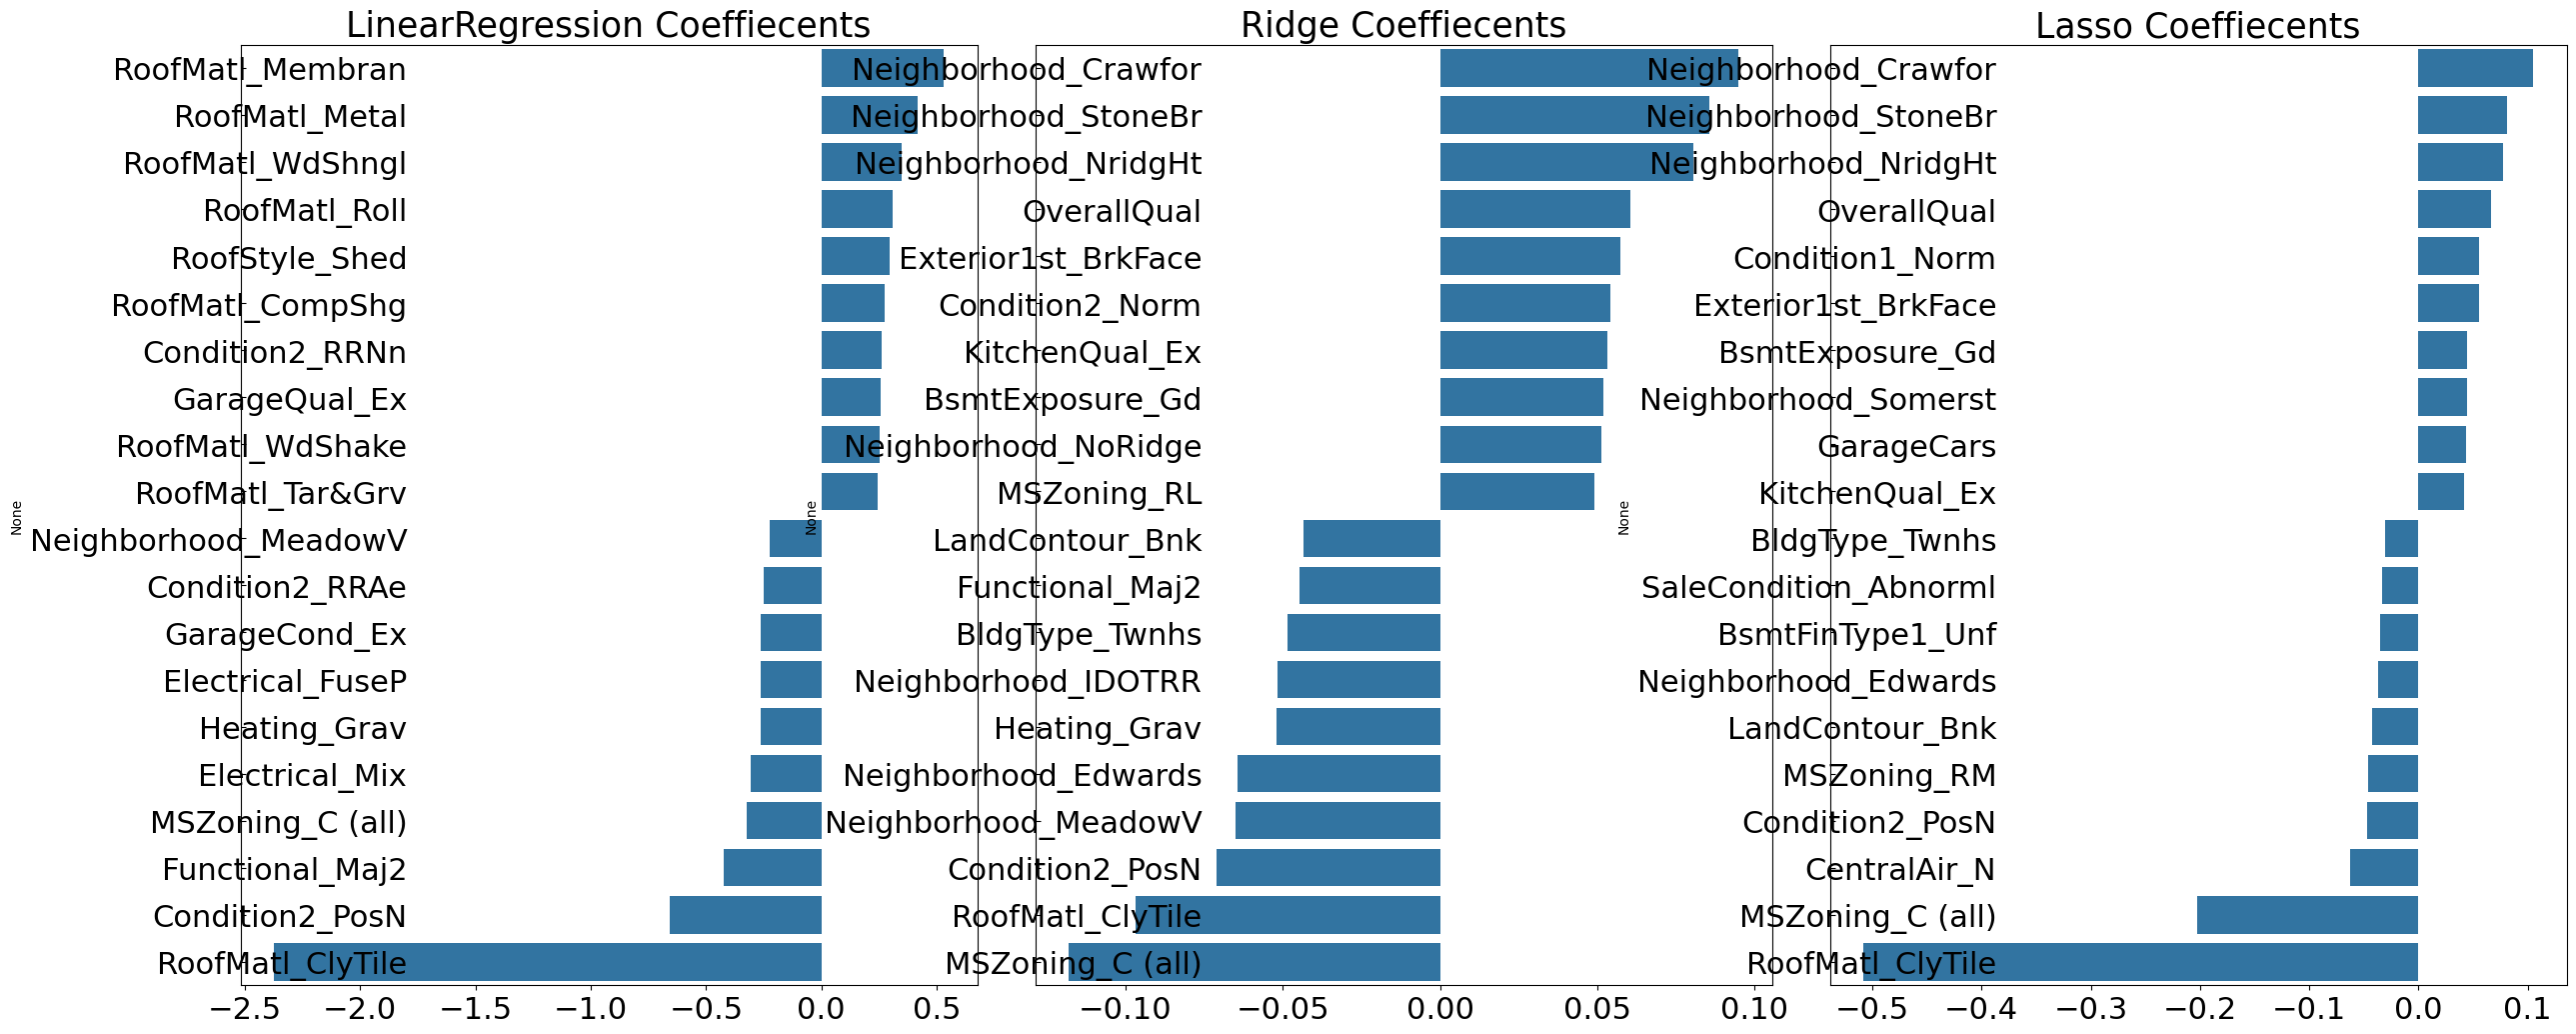

In [209]:
# 앞의 최적화 alpha 값으로 학습 데이터로 학습, 테스트 데이터로 예측 및 평가 수행 
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
ridge_reg = Ridge(alpha=12)
ridge_reg.fit(X_train, y_train)
lasso_reg = Lasso(alpha=0.001)
lasso_reg.fit(X_train, y_train)

# 모든 모델의 RMSE 출력
models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models)

# 모든 모델의 회귀계수 시각화
models = [lr_reg, ridge_reg, lasso_reg]
visualize_coefficient(models)

➡️ alpha 값 최적화 이후 테스트 데이터 세트의 예측 성능이 더 좋아짐 

- 모델 튜닝 진행 - 데이터 분포도 / outlier 데이터 처리

`skew()`함수의 반환값이 1 이상의 값인 피처만 추출해 왜곡 정도를 완화하기 위해 로그 변환을 적용하기 <br>이때 카테고리 숫자형 피처는 제외해야함

In [213]:
from scipy.stats import skew

# object가 이닌 숫자형 피처의 칼럼 index 객체 추출
features_index = house_df.dtypes[house_df.dtypes != 'object'].index
# house_df에 칼럼 index를 []로 입력하면 해당하는 칼럼 데이터 세트 반환. apply lambda로 skew() 호출
skew_features = house_df[features_index].apply(lambda x:skew(x))
# skew 정도가 1 이상인 칼럼만 추출
skew_features_top = skew_features[skew_features > 1]
print(skew_features_top.sort_values(ascending=False))

MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
MasVnrArea        2.673661
LotFrontage       2.382499
OpenPorchSF       2.361912
BsmtFinSF1        1.683771
WoodDeckSF        1.539792
TotalBsmtSF       1.522688
MSSubClass        1.406210
1stFlrSF          1.375342
GrLivArea         1.365156
dtype: float64


In [214]:
house_df[skew_features_top.index] = np.log1p(house_df[skew_features_top.index])
# 왜곡 정도가 높은 피처들에 대해 로그변환 

➡️ 다시 원핫인코딩 해보기 

In [216]:
# 왜곡 정도가 높은 피처를 로그 변환했으므로 다시 원-핫 인코딩을 적용하고 피처/타깃 데이터 세트 생성
house_df_ohe = pd.get_dummies(house_df)
y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1, inplace=False)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=156)

# 피처를 로그 변환한 후 다시 최적 하이퍼 파라미터와 RMSE 출력
ridge_params = {'alpha': [0.05, 0.1, 1, 5, 8, 10, 12, 15, 20]}
lasso_params = {'alpha': [0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1, 5, 10]}
print_best_params(ridge_reg, ridge_params)
print_best_params(lasso_reg, lasso_params)

Ridge 5 CV 시 최적 평균 RMSE 값:0.1275, 최적 alpha:{'alpha': 10}
Lasso 5 CV 시 최적 평균 RMSE 값:0.1252, 최적 alpha:{'alpha': 0.001}


➡️ 릿지 모델의 경우 최적 알파값이 변경됨 
<br>
➡️ 두 모델 모두 RMSE값이 향상됨 

LinearRegression  로그 변환된 RMSE: 0.128
Ridge  로그 변환된 RMSE: 0.122
Lasso  로그 변환된 RMSE: 0.119


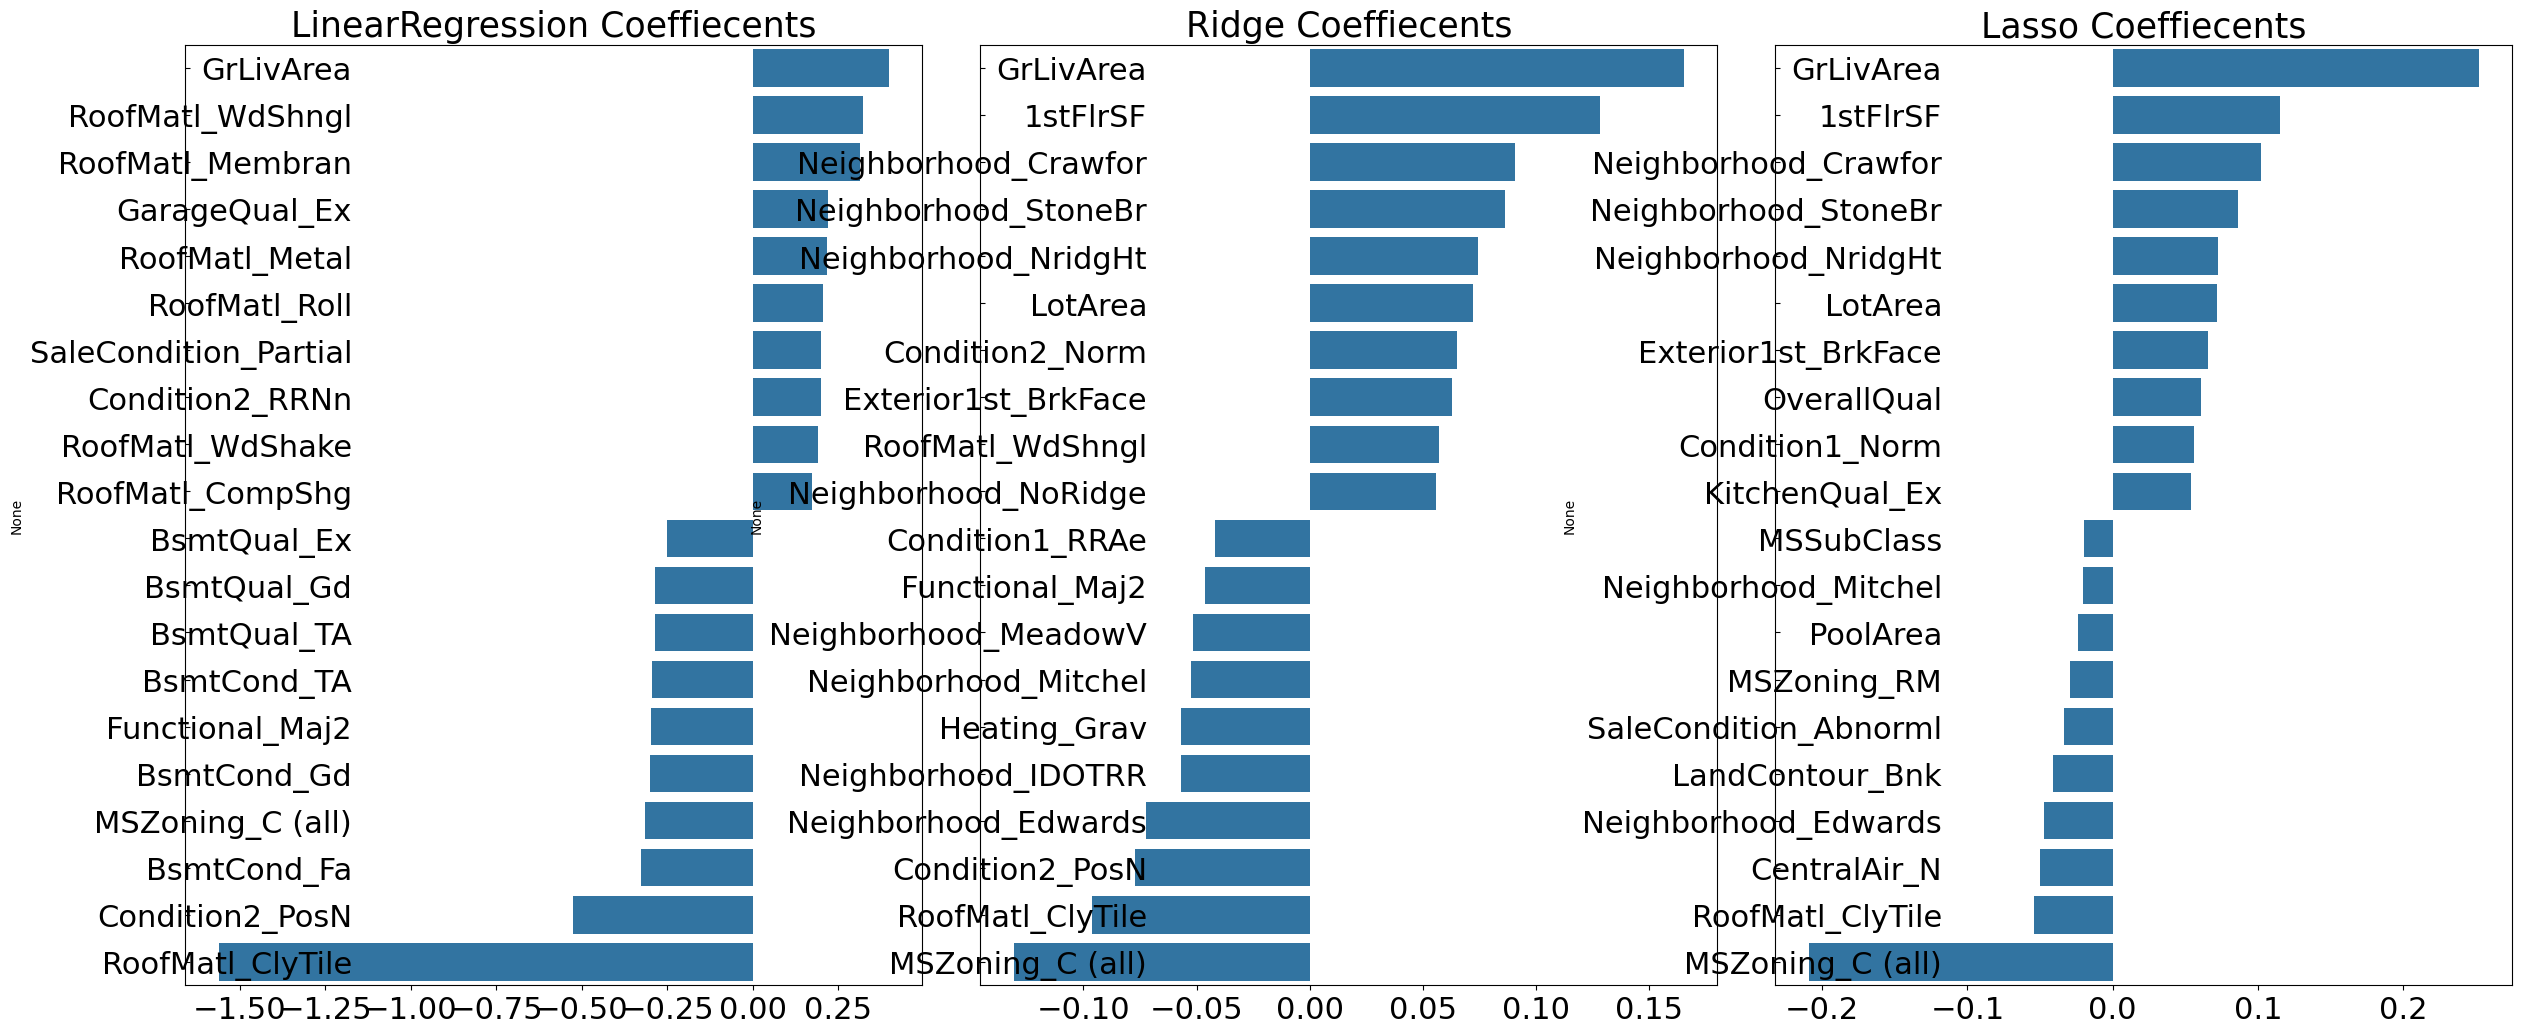

In [219]:
# 앞의 최적화 alpha 값으로 학습 데이터로 학습, 테스트 데이터로 예측 및 평가 수행 
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
ridge_reg = Ridge(alpha=10)
ridge_reg.fit(X_train, y_train)
lasso_reg = Lasso(alpha=0.001)
lasso_reg.fit(X_train, y_train)

# 모든 모델의 RMSE 출력
models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models)

# 모든 모델의 회귀계수 시각화
models = [lr_reg, ridge_reg, lasso_reg]
visualize_coefficient(models)

➡️ 이제 모두 비슷한 분포를 보임
<br>➡️ 이상치를 더 살펴보자

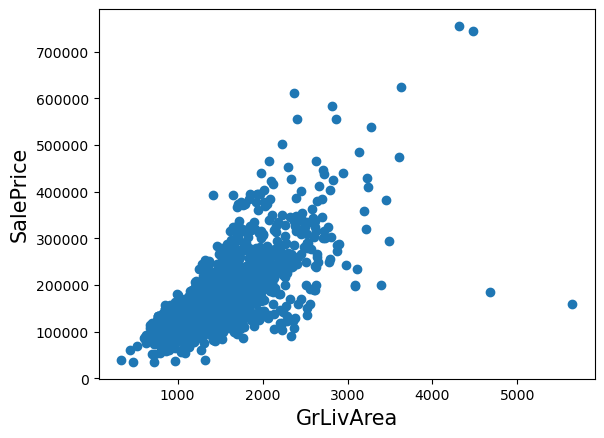

In [224]:
plt.scatter(x=house_df_org['GrLivArea'], y=house_df_org['SalePrice'])
plt.ylabel('SalePrice', fontsize=15)
plt.xlabel('GrLivArea',fontsize=15)
plt.show()

➡️ 오른쪽 이상치 두개 필터링 하자

In [226]:
# GrLivArea와 SalePrice 모두 로그 변호나 되었으므로 이를 반영한 조건 생성
cond1 = house_df_ohe['GrLivArea'] > np.log1p(4000)
cond2 = house_df_ohe['SalePrice'] < np.log1p(500000)
outlier_index = house_df_ohe[cond1&cond2].index

print('이상치 레코드 index :', outlier_index.values)
print('이상치 삭제 전 house_df_ohe shape:', house_df_ohe.shape)

# DataFrame의 인덱스를 이용해 이상치 레코드 삭제
house_df_ohe.drop(outlier_index, axis=0, inplace=True)
print('이상치 삭제 후 house_df_ohe shape:', house_df_ohe.shape)

이상치 레코드 index : [ 523 1298]
이상치 삭제 전 house_df_ohe shape: (1460, 270)
이상치 삭제 후 house_df_ohe shape: (1458, 270)


➡️ 두 이상치 데이터가 삭제 됨

In [234]:
y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1, inplace=False)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size = 0.2, random_state=156)

ridge_params = {'alpha': [0.05, 0.1, 1, 5, 8, 10, 12, 15, 20]}
lasso_params = {'alpha': [0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1, 5, 10]}
print_best_params(ridge_reg, ridge_params)
print_best_params(lasso_reg, lasso_params)

Ridge 5 CV 시 최적 평균 RMSE 값:0.1125, 최적 alpha:{'alpha': 8}
Lasso 5 CV 시 최적 평균 RMSE 값:0.1122, 최적 alpha:{'alpha': 0.001}


➡️ 예측 수치가 매우 크게 향상됨 
<br>
➡️ 이상치 제거가 중요하다!

LinearRegression  로그 변환된 RMSE: 0.129
Ridge  로그 변환된 RMSE: 0.103
Lasso  로그 변환된 RMSE: 0.1


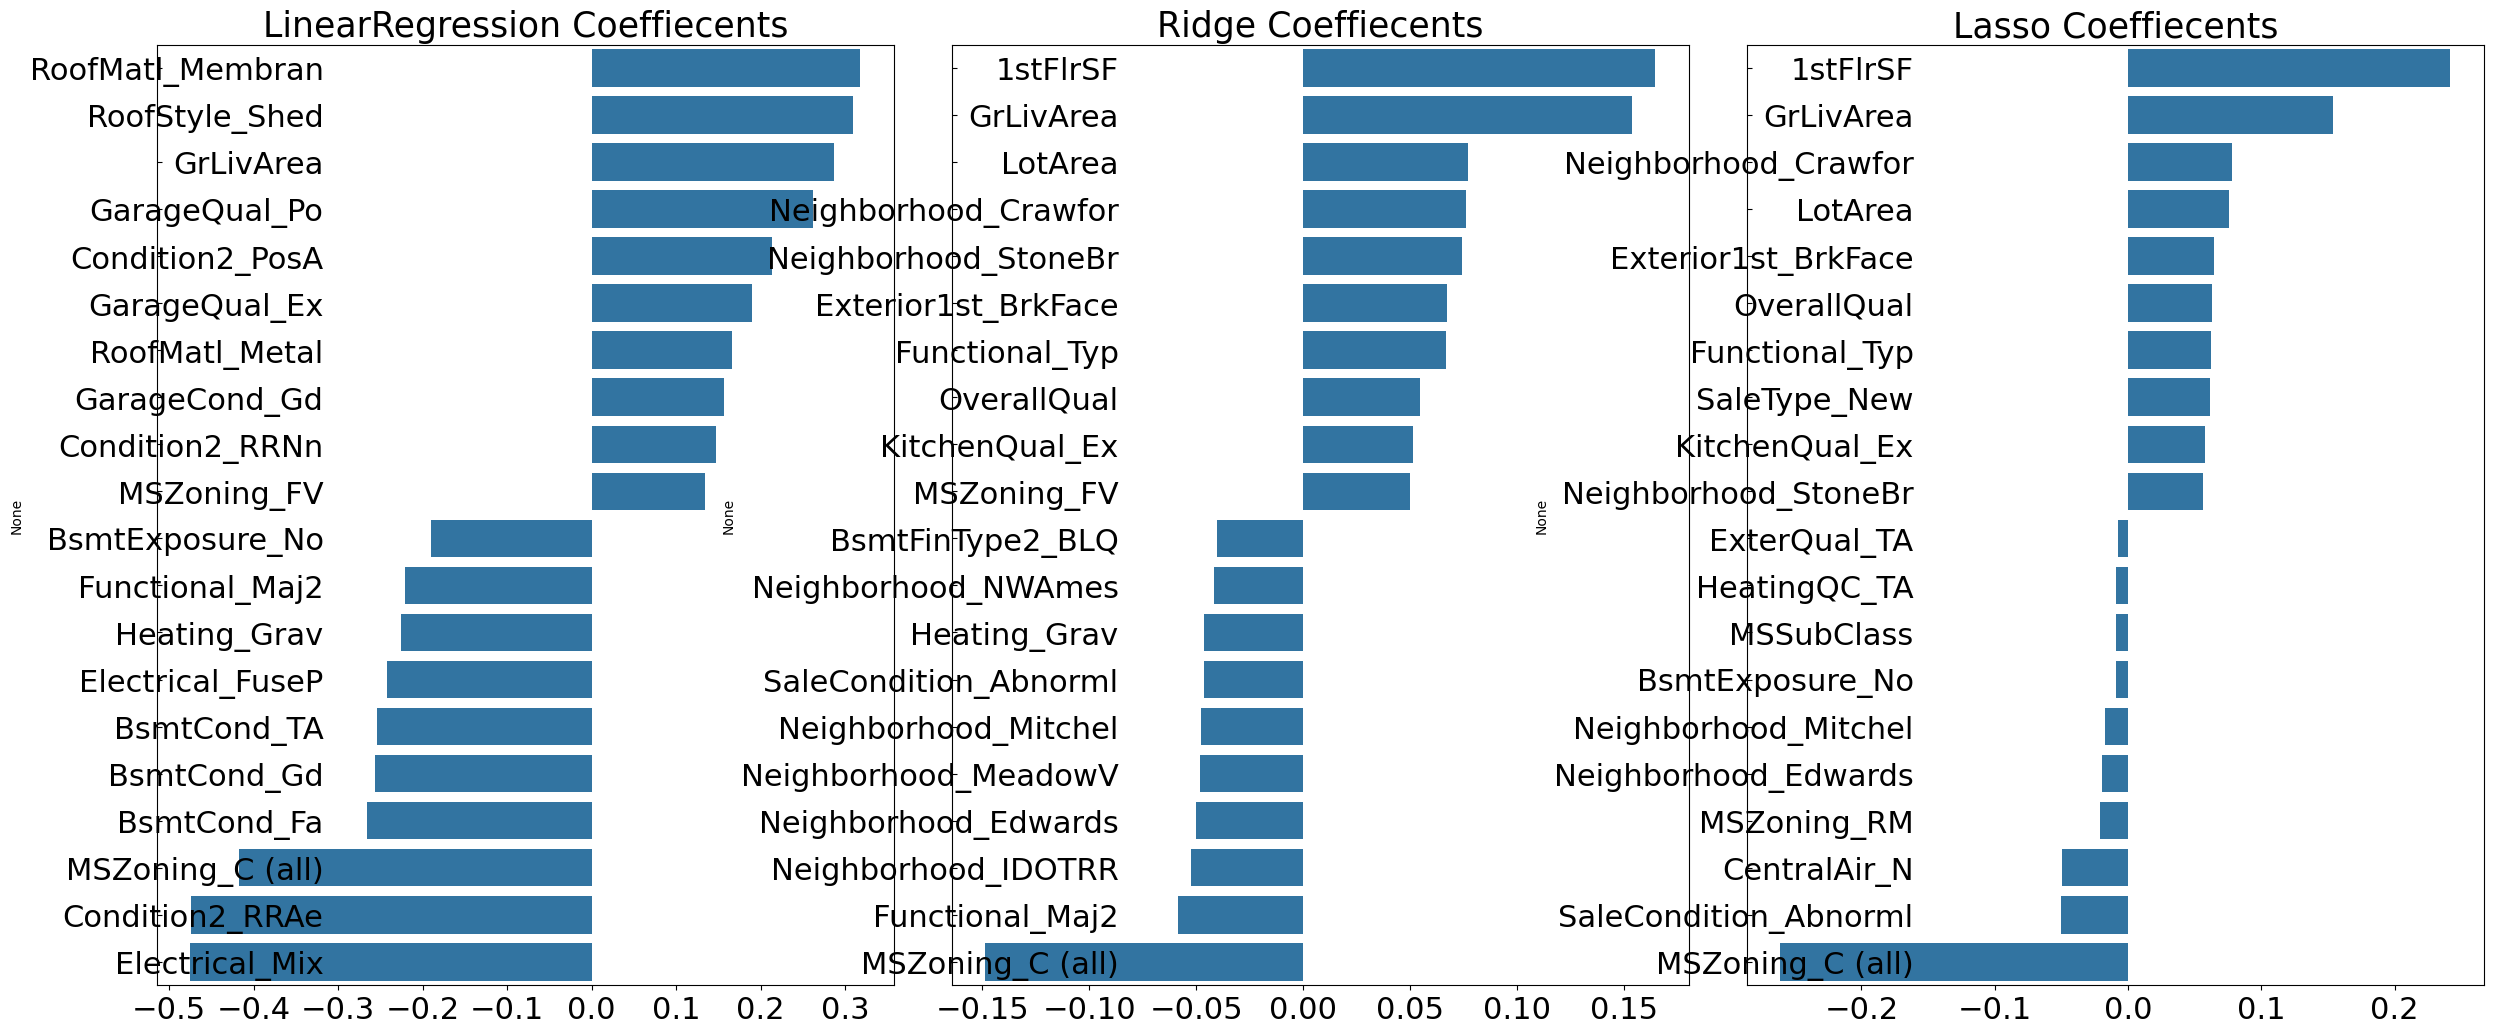

In [237]:
# 앞의 최적화 alpha 값으로 학습 데이터로 학습, 테스트 데이터로 예측 및 평가 수행 
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
ridge_reg = Ridge(alpha=10)
ridge_reg.fit(X_train, y_train)
lasso_reg = Lasso(alpha=0.001)
lasso_reg.fit(X_train, y_train)

# 모든 모델의 RMSE 출력
models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models)

# 모든 모델의 회귀계수 시각화
models = [lr_reg, ridge_reg, lasso_reg]
visualize_coefficient(models)

**✅ 회귀 트리 모델 학습/예측/평가**

- XGB

In [241]:
from xgboost import XGBRegressor

xgb_params = {'n_estimators':[1000]}
xgb_reg = XGBRegressor(n_estimators=1000, learning_rate=0.05, colsample_bytree=0.5, subsample=0.8)
print_best_params(xgb_reg, xgb_params)

XGBRegressor 5 CV 시 최적 평균 RMSE 값:0.1202, 최적 alpha:{'n_estimators': 1000}


- LightGBM

In [246]:
from lightgbm import LGBMRegressor

lgbm_params = {'n_estimators':[1000]}
lgbm_reg = LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=4, subsample=0.6, colsample_bytree=0.4, reg_lambda=10, n_jobs=-1)
print_best_params(lgbm_reg, lgbm_params)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002528 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3155
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 171
[LightGBM] [Info] Start training from score 12.021352
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002118 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3167
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 168
[LightGBM] [Info] Start training from score 12.023516
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM]

**✅ 회귀 모델의 예측 결과 혼합을 통한 최종 예측** 

일정 비율로 예측값을 더해 최종 값을 예측하자!

In [252]:
def get_rmse_pred(preds):
    for key in preds.keys():
        pred_value = preds[key]
        mse = mean_squared_error(y_test, pred_value)
        rmse = np.sqrt(mse)
        print('{0} 모델의 RMSE: {1}'.format(key, rmse))

# 개별 모델의 학습
ridge_reg = Ridge(alpha=8)
ridge_reg.fit(X_train, y_train)
lasso_reg = Lasso(alpha=0.001)
lasso_reg.fit(X_train, y_train)
# 개별 모델 예측
ridge_pred = ridge_reg.predict(X_test)
lasso_pred = lasso_reg.predict(X_test)

# 개별 모델 예측값 혼합으로 최종 예측값 도출
pred = 0.4*ridge_pred + 0.6*lasso_pred
preds = {'최종 혼합' : pred,
         'Ridge':ridge_pred,
         'Lasso':lasso_pred}

# 최종 혼합 모델, 개별 모델 RMSE값 출력
get_rmse_pred(preds)

최종 혼합 모델의 RMSE: 0.10006075517615193
Ridge 모델의 RMSE: 0.10340697165289348
Lasso 모델의 RMSE: 0.10024171179335338


➡️ 약간 개선됨 

In [255]:
xgb_reg = XGBRegressor(n_estimators=1000, learning_rate=0.05, colsample_bytree=0.5, subsample=0.8)
lgbm_reg = LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=4, subsample=0.6, colsample_bytree=0.4, reg_alpha=10, n_jobs=-1)

xgb_reg.fit(X_train, y_train)
lgbm_reg.fit(X_train, y_train)
xgb_pred = xgb_reg.predict(X_test)
lgbm_pred = lgbm_reg.predict(X_test)
pred = 0.5*xgb_pred + 0.5*lgbm_pred
preds = {'최종 혼합':pred,
         'XGBM':xgb_pred,
         'LGBM':lgbm_pred}

get_rmse_pred(preds)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000801 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3174
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 172
[LightGBM] [Info] Start training from score 12.025343
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

➡️ 개별 모델보다 조금 더 향상됨

**✅ 스태킹 앙상블 모델을 통한 회귀 예측**
<br>개별적인 기반 모델 + 개별기반 모델의 예측 데이터를 학습 데이터로 사용하는 최종 메타 모델'

- 데이터 세트 생성 함수 

In [260]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# 개별 기반 모델에서 최종 메타 모델이 사용할 학습 및 테스트용 데이터를 생성하기 위한 함수
def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds):
    # 지정된 n_folds값으로 KFold 생성
    kf = KFold(n_splits=n_folds, shuffle=False)
    # 추후에 메타 모델이 사용할 학습 데이터 반환을 위한 넘파이 배열 초기화
    train_fold_pred = np.zeros((X_train_n.shape[0],1))
    test_pred = np.zeros((X_test_n.shape[0], n_folds))
    print(model.__class__.__name__,' model 시작')

    for folder_counter, (train_index, valid_index) in enumerate(kf.split(X_train_n)):
        # 입력된 학습 데이터에서 기반 모델이 학습/예측할 폴드 데이터 세트 추출
        print('\t 폴드 세트:', folder_counter,' 시작')
        X_tr = X_train_n[train_index]
        y_tr = y_train_n[train_index]
        X_te = X_train_n[valid_index]

        # 폴드 세트 내부에서 다시 만들어진 학습 데이터로 기반 모델의 학습 수행
        model.fit(X_tr, y_tr)
        # 폴드 세트 내부에서 다시 만들어진 검증 데이터로 기반 모델 예측 후 데이터 저장
        train_fold_pred[valid_index, :] = model.predict(X_te).reshape(-1,1)
        # 입력된 원본 테스트 데이터를 폴드 세트 내 학습된 기반 모델에서 예측 후 데이터 저장
        test_pred[:, folder_counter] = model.predict(X_test_n)

    # 폴드 세트 내에서 원본 테스트 데이터를 예측한 데이터를 평균하여 테스트 데이터로 생성
    test_pred_mean = np.mean(test_pred, axis=1).reshape(-1,1)

    # train_flod_pred는 최종 메타 모델이 사용하는 학습 데이터, test_pred_mean 테스트 데이터 
    return train_fold_pred, test_pred_mean

- 모델별 학습 피처 데이터 세트와 테스트 피처 데이터 세트를 추출

In [265]:
# get_stacking_base_datasets()는 넘파이 ndarray를 인자로 사용하므로 DataFrame을 넘파이로 변환
X_train_n = X_train.values
X_test_n = X_test.values
y_train_n = y_train.values

# 각 개별 기반 Base 모델이 생성한 학습용/테스트용 데이터 반환
ridge_train, ridge_test = get_stacking_base_datasets(ridge_reg, X_train_n, y_train_n, X_test_n, 5)
lasso_train, lasso_test = get_stacking_base_datasets(lasso_reg, X_train_n, y_train_n, X_test_n, 5)
xgb_train, xgb_test = get_stacking_base_datasets(xgb_reg, X_train_n, y_train_n, X_test_n, 5)  
lgbm_train, lgbm_test = get_stacking_base_datasets(lgbm_reg, X_train_n, y_train_n, X_test_n, 5)

Ridge  model 시작
	 폴드 세트: 0  시작
	 폴드 세트: 1  시작
	 폴드 세트: 2  시작
	 폴드 세트: 3  시작
	 폴드 세트: 4  시작
Lasso  model 시작
	 폴드 세트: 0  시작
	 폴드 세트: 1  시작
	 폴드 세트: 2  시작
	 폴드 세트: 3  시작
	 폴드 세트: 4  시작
XGBRegressor  model 시작
	 폴드 세트: 0  시작
	 폴드 세트: 1  시작
	 폴드 세트: 2  시작
	 폴드 세트: 3  시작
	 폴드 세트: 4  시작
LGBMRegressor  model 시작
	 폴드 세트: 0  시작
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001888 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2924
[LightGBM] [Info] Number of data points in the train set: 932, number of used features: 156
[LightGBM] [Info] Start training from score 12.035561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training b

In [267]:
# 개별 모델이 반환한 학습 및 테스트용 데이터 세트를 Stacking 형태로 결합
Stack_final_X_train = np.concatenate((ridge_train, lasso_train, xgb_train, lgbm_train), axis=1)
Stack_final_X_test = np.concatenate((ridge_test, lasso_test, xgb_test, lgbm_test), axis=1)

# 최종 메타 모델은 라쏘 모델을 적용
meta_model_lasso = Lasso(alpha=0.0005)

#기반 모델의 예측값을 기반으로 새롭게 만들어진 학습 및 테스트용 데이터로 예측하고 RMSE 측정
meta_model_lasso.fit(Stack_final_X_train, y_train)
final = meta_model_lasso.predict(Stack_final_X_test)
mse = mean_squared_error(y_test , final)
rmse = np.sqrt(mse)
print('스태킹 회귀 모델의 최종 RMSE 값은:', rmse)

스태킹 회귀 모델의 최종 RMSE 값은: 0.09712287071068174


# **캐글 1 - Insurance prediction**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

**☑️ Reading the dataset**

In [6]:
df = pd.read_csv('./insurance.csv')

**☑️ Data Overview**

In [9]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [13]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [15]:
df.shape

(1338, 7)

**☑️ Checking the missing data**

In [20]:
df.isnull().sum().sort_values(ascending=False)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

➡️ missing data 없음


**☑️ Distribution Plot**

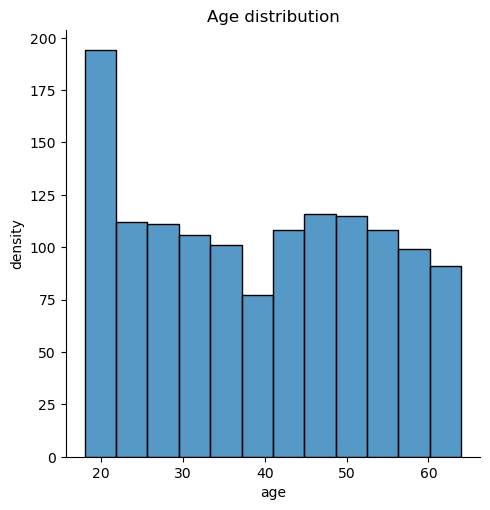

In [25]:
sns.displot(df['age'])
plt.title('Age distribution')
plt.ylabel('density')
plt.xlabel('age')
plt.show()

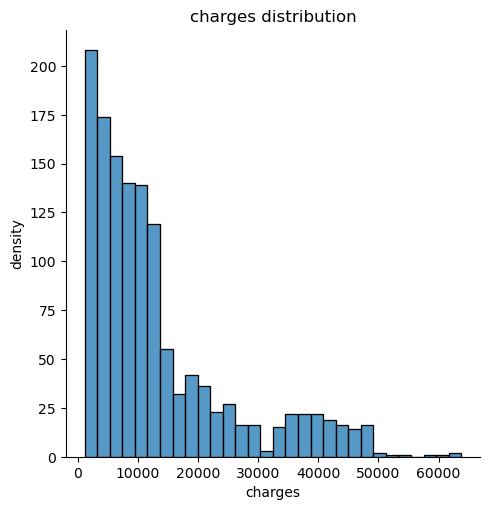

In [31]:
sns.displot(df['charges'])
plt.title('charges distribution')
plt.ylabel('density')
plt.xlabel('charges')
plt.show()

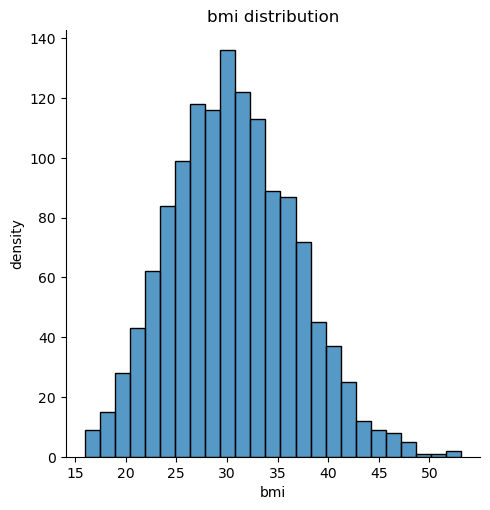

In [33]:
sns.displot(df['bmi'])
plt.title('bmi distribution')
plt.ylabel('density')
plt.xlabel('bmi')
plt.show()

**☑️ Count Plot**

In [36]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

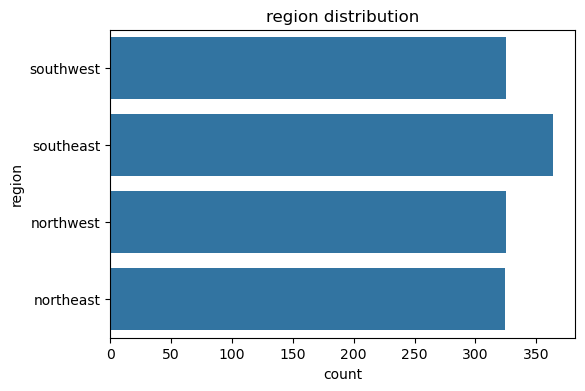

In [38]:
fig = plt.figure(figsize = (6,4))
sns.countplot(df['region'])
plt.title('region distribution')
plt.show()

In [40]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

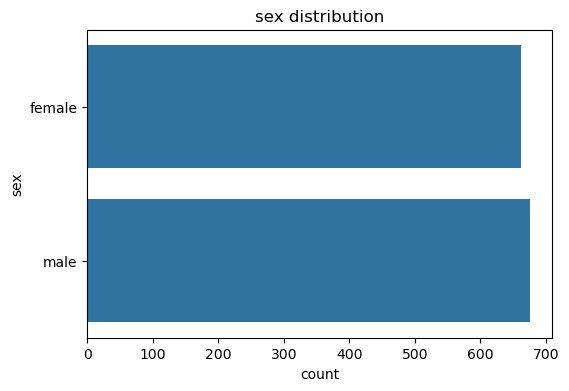

In [44]:
fig = plt.figure(figsize = (6,4))
sns.countplot(df['sex'])
plt.title('sex distribution')
plt.show()

In [46]:
df['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

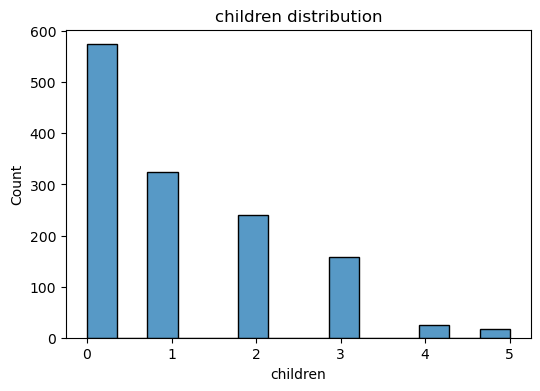

In [61]:
fig = plt.figure(figsize=(6,4))
sns.histplot(df['children'])
plt.title('children distribution')
plt.show()

➡️ 연속형 변수라 histplot으로 시각화

**☑️ Checking the correlation**

In [59]:
df['sex'] = pd.factorize(df['sex'])[0] +1
df['region'] = pd.factorize(df['region'])[0]+1
df['smoker'] = pd.factorize(df['smoker'])[0]+1
corr = df.corr()
corr['charges'].sort_values(ascending=False)

charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
region      0.006208
smoker     -0.787251
Name: charges, dtype: float64

**☑️ Correlation Plot**

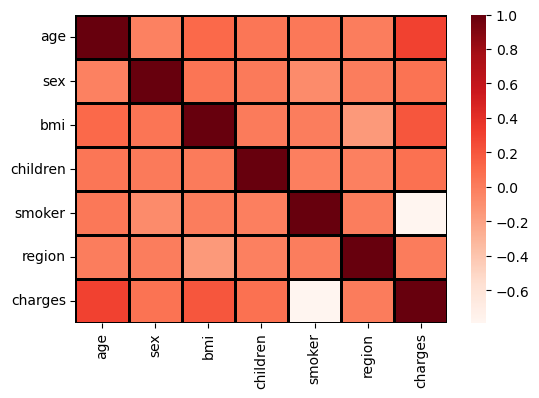

In [65]:
fig = plt.figure(figsize=(6,4))
data_ploting = df.corr(method ='pearson')
sns.heatmap(data_ploting, cmap='Reds', linecolor='black', linewidths=2)
plt.show()

**☑️ Pair Plot**

<Figure size 600x400 with 0 Axes>

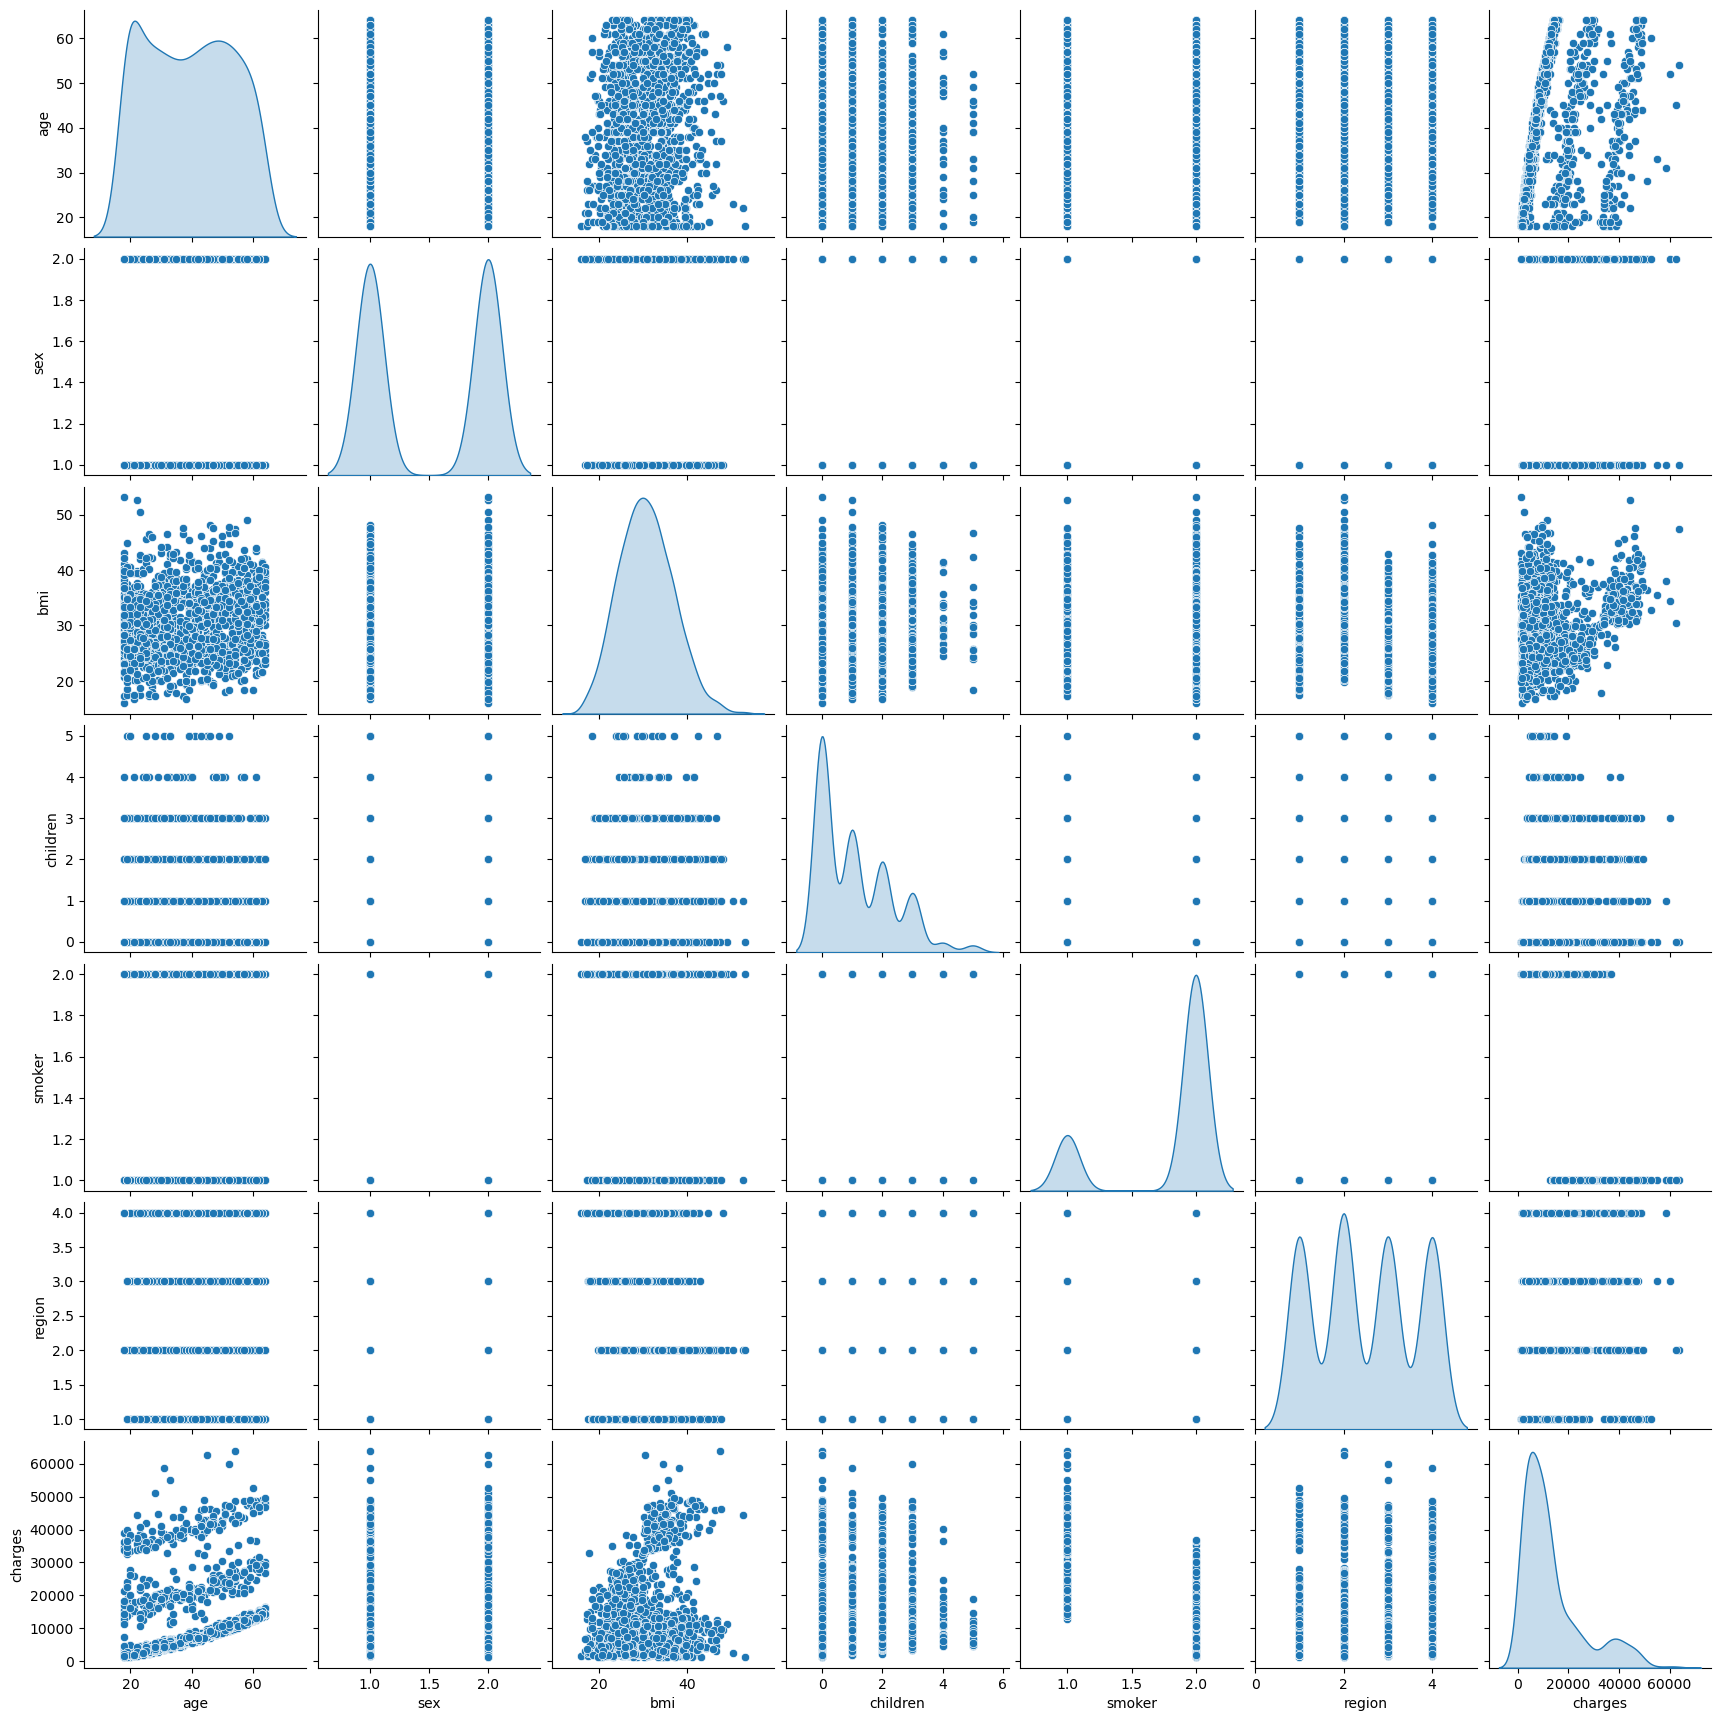

In [68]:
fig = plt.figure(figsize=(6,4))
sns.pairplot(df, diag_kind='kde')

**☑️ Train and Test Split**

In [78]:
X = df.drop('charges', axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

**☑️ Scalling data**

In [80]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

**☑️ Linear Regression Model**

In [83]:
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train_scaled, y_train)

LinearRegression()

In [87]:
y_pred = linear_reg_model.predict(X_test_scaled)
y_pred = pd.DataFrame(y_pred)

MAE_li_reg = metrics.mean_absolute_error(y_test, y_pred)
MSE_li_reg = metrics.mean_squared_error(y_test, y_pred)
RMSE_li_reg = np.sqrt(MSE_li_reg)
pd.DataFrame([MAE_li_reg, MSE_li_reg, RMSE_li_reg], 
             index=['MAE_li_reg', 'MSE_li_reg', 'RMSE_li_reg'],
             columns = ['Metrics'])

,Metrics
MAE_li_reg,3.990250e+03
MSE_li_reg,3.353013e+07
RMSE_li_reg,5.790521e+03


In [89]:
scores = cross_val_score(linear_reg_model, X_train_scaled, y_train, cv=5)
print(np.sqrt(scores))

[0.88791389 0.85653048 0.84404195 0.87198372 0.84417492]


In [91]:
r2_score(y_test, linear_reg_model.predict(X_test_scaled))

0.7613126015198816

**☑️ Gradient Boosting Regressor Model**

In [94]:
Gradient_model = GradientBoostingRegressor()
Gradient_model.fit(X_train_scaled, y_train)

GradientBoostingRegressor()

In [96]:
y_pred = Gradient_model.predict(X_test_scaled)
y_pred = pd.DataFrame(y_pred)
MAE_gradient = metrics.mean_absolute_error(y_test, y_pred)
MSE_gradient = metrics.mean_squared_error(y_test, y_pred)
RMSE_gradient = np.sqrt(MSE_gradient)
pd.DataFrame([MAE_gradient, MSE_gradient, RMSE_gradient], 
             index = ['MAE_gradient', 'MSE_gradient', 'RMSE_gradient'],
             columns = ['Metrics'])

,Metrics
MAE_gradient,2.528851e+03
MSE_gradient,2.110725e+07
RMSE_gradient,4.594262e+03


In [98]:
scores = cross_val_score(Gradient_model, X_train_scaled, y_train, cv=5)
print(np.sqrt(scores))

[0.94594744 0.91416389 0.91670616 0.92571764 0.91717029]


In [100]:
r2_score(y_test, Gradient_model.predict(X_test_scaled))

0.849746079970233

**☑️ XGB Regressor Model**

In [103]:
XGB_model = XGBRegressor()
XGB_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [105]:
y_pred = XGB_model.predict(X_test_scaled)
y_pred = pd.DataFrame(y_pred)
MAE_XGB = metrics.mean_absolute_error(y_test, y_pred)
MSE_XGB = metrics.mean_squared_error(y_test, y_pred)
RMSE_XGB = np.sqrt(MSE_XGB)
pd.DataFrame([MAE_XGB, MSE_XGB, RMSE_XGB], 
             index=['MAE_XGB', 'MSE_XGB', 'RMSE_XGB'],
             columns=['Metrics'])

,Metrics
MAE_XGB,3.142590e+03
MSE_XGB,2.976529e+07
RMSE_XGB,5.455757e+03


In [107]:
scores = cross_val_score(XGB_model, X_train_scaled, y_train, cv=5)
print(np.sqrt(scores))

[0.91782241 0.88730325 0.90410079 0.90440364 0.88383429]


In [111]:
r2_score(y_test, XGB_model.predict(X_test_scaled))

0.7881129907007072

**☑️ Decision Tree Regressor Model**

In [114]:
tree_reg_model =DecisionTreeRegressor()
tree_reg_model.fit(X_train_scaled, y_train)

DecisionTreeRegressor()

In [116]:
y_pred = tree_reg_model.predict(X_test_scaled)
y_pred = pd.DataFrame(y_pred)
MAE_tree_reg= metrics.mean_absolute_error(y_test, y_pred)
MSE_tree_reg = metrics.mean_squared_error(y_test, y_pred)
RMSE_tree_reg =np.sqrt(MSE_tree_reg)

pd.DataFrame([MAE_tree_reg, MSE_tree_reg, RMSE_tree_reg],
             index=['MAE_tree_reg', 'MSE_tree_reg', 'RMSE_tree_reg'], 
             columns=['Metrics'])

,Metrics
MAE_tree_reg,3.486256e+03
MSE_tree_reg,5.047454e+07
RMSE_tree_reg,7.104544e+03


In [118]:
scores = cross_val_score(tree_reg_model, X_train_scaled, y_train, cv=5)
print(np.sqrt(scores))

[0.83713034 0.81240908 0.85686413 0.87372299 0.8430027 ]


In [120]:
r2_score(y_test, tree_reg_model.predict(X_test_scaled))

0.6406922168767606

**☑️ Random Forest Regressor Model**

In [125]:
forest_reg_model =RandomForestRegressor()
forest_reg_model.fit(X_train_scaled, y_train)

RandomForestRegressor()

In [127]:
y_pred = forest_reg_model.predict(X_test_scaled)
y_pred = pd.DataFrame(y_pred)
MAE_forest_reg= metrics.mean_absolute_error(y_test, y_pred)
MSE_forest_reg = metrics.mean_squared_error(y_test, y_pred)
RMSE_forest_reg =np.sqrt(MSE_forest_reg)
pd.DataFrame([MAE_forest_reg, MSE_forest_reg, RMSE_forest_reg], 
             index=['MAE_forest_reg', 'MSE_forest_reg', 'RMSE_forest_reg'],
             columns=['Metrics'])

,Metrics
MAE_forest_reg,2.931067e+03
MSE_forest_reg,2.550768e+07
RMSE_forest_reg,5.050512e+03


In [129]:
scores = cross_val_score(forest_reg_model, X_train_scaled, y_train, cv=5)
print(np.sqrt(scores))

[0.94408292 0.90409264 0.92259743 0.91523305 0.9039392 ]


In [131]:
r2_score(y_test, forest_reg_model.predict(X_test_scaled))

0.8184212052030678

# **캐글 2 - Avocado Price Regression with PyCaret & EDA**

**🥑 PyCaret란?**


PyCaret은 파이썬 기반의 오픈소스 저코드(Low-Code) 머신러닝 라이브러리로, 데이터 과학자가 복잡한 머신러닝 워크플로우를 몇 줄의 코드만으로 자동화할 수 있게 도와줌

PyCaret은 반복적이고 시간이 많이 드는 모델 실험 및 비교 과정을 자동화해주기 때문에, 핵심 문제 해결에 집중할 수 있다. 수백 줄의 코드를 몇 줄로 줄여주어 실험 주기를 크게 단축시키고, 다양한 모델을 손쉽게 비교/최적화할 수 있다!

**🥑라이브러리 설치**

In [8]:
!pip install pycaret
!pip install markupsafe==2.0.1
!pip jinja2

  Using cached pycaret-3.3.2-py3-none-any.whl.metadata (17 kB)
  Using cached ipywidgets-8.1.6-py3-none-any.whl.metadata (2.4 kB)
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached pandas-2.1.4-cp312-cp312-win_amd64.whl.metadata (18 kB)
  Using cached scipy-1.11.4-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.3.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pyod-2.0.5-py3-none-any.whl.metadata (46 kB)
  Using cached imbalanced_learn-0.13.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached category_encoders-2.8.1-py3-none-any.whl.metadata (7.9 kB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
  Using cached numba-0.61.2-cp312-cp312-win_amd64.whl.metadata (2.9 kB)
  Using cached importlib_metadata-8.7.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached deprecation-2.1.0-py2.py3-none-any.whl.metadata (4.6 kB)
  Using cached xxhash-3.5.0-c

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
librosa 0.11.0 requires audioread>=2.1.9, which is not installed.
librosa 0.11.0 requires lazy_loader>=0.1, which is not installed.
librosa 0.11.0 requires msgpack>=1.0, which is not installed.
librosa 0.11.0 requires pooch>=1.1, which is not installed.
librosa 0.11.0 requires soundfile>=0.12.1, which is not installed.

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached MarkupSafe-2.0.1-cp312-cp312-win_amd64.whl
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
werkzeug 3.0.6 requires MarkupSafe>=2.1.1, but you have markupsafe 2.0.1 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: unknown command "jinja2"



In [1]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pycaret
import warnings
import jinja2

from sklearn.preprocessing import LabelEncoder
from scipy import stats
from scipy.stats import *
from pycaret.regression import *

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

**🥑 컬러 팔레트 설정**

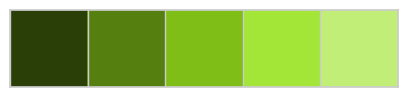

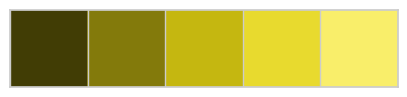

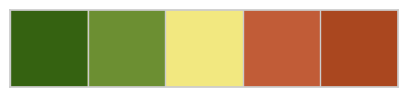

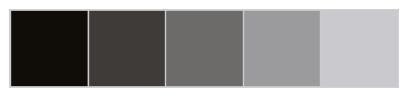

In [3]:
olive_grad = ['#2A3F07', '#557F0F', '#7FBE17', '#A4E637', '#C1EE76']
yellow_grad = ['#413D05', '#837A0B', '#C5B710', '#E8DA2E', '#F9EE6A']
color_mix = ['#356211', '#6C8F32', '#F2E880', '#C15C37', '#AA471F']
black_grad = ['#100C07', '#3E3B39', '#6D6A6A', '#9B9A9C', '#CAC9CD']

sns.palplot(olive_grad)
sns.palplot(yellow_grad)
sns.palplot(color_mix)
sns.palplot(black_grad)

**🥑 데이터 검토**

In [7]:
ds = pd.read_csv('./avocado.csv')
ds.head().style.background_gradient(cmap='Greens').set_properties(**{'font-family': 'Segoe UI'})

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.330000,64236.620000,1036.740000,54454.850000,48.160000,8696.870000,8603.620000,93.250000,0.000000,conventional,2015,Albany
1,1,2015-12-20,1.350000,54876.980000,674.280000,44638.810000,58.330000,9505.560000,9408.070000,97.490000,0.000000,conventional,2015,Albany
2,2,2015-12-13,0.930000,118220.220000,794.700000,109149.670000,130.500000,8145.350000,8042.210000,103.140000,0.000000,conventional,2015,Albany
3,3,2015-12-06,1.080000,78992.150000,1132.000000,71976.410000,72.580000,5811.160000,5677.400000,133.760000,0.000000,conventional,2015,Albany
4,4,2015-11-29,1.280000,51039.600000,941.480000,43838.390000,75.780000,6183.950000,5986.260000,197.690000,0.000000,conventional,2015,Albany


In [9]:
print('\033[92m\033[1m'+'.: Imported Dataset Info :.'+'\033[0m')
print('\033[92m*' * 30+'\033[0m')
print('Total Rows:'+'\033[92m\033[1m', ds.shape[0])
print('\033[0m'+'Total Columns:'+'\033[92m\033[1m', ds.shape[1])
print('\033[0m\033[92m'+'*' * 30+'\033[0m')
print('\n')

print('\033[92m\033[1m'+'.: Dataset Details :.'+'\033[0m')
print('\033[0m\033[92m'+'*' * 30+'\033[0m')
ds.info(memory_usage = False)

.: Imported Dataset Info :.
******************************
Total Rows: 18249
Total Columns: 14
******************************


.: Dataset Details :.
******************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), in

➡️ 14개 칼럼 + 18249개 관측치
<br>
➡️ 결측값 없음

**🥑 데이터 탐색 - Categorical Variable**

- Type

****************************************
.: Total Avocado based on each Type :.
****************************************


type
conventional    9126
organic         9123
Name: count, dtype: int64

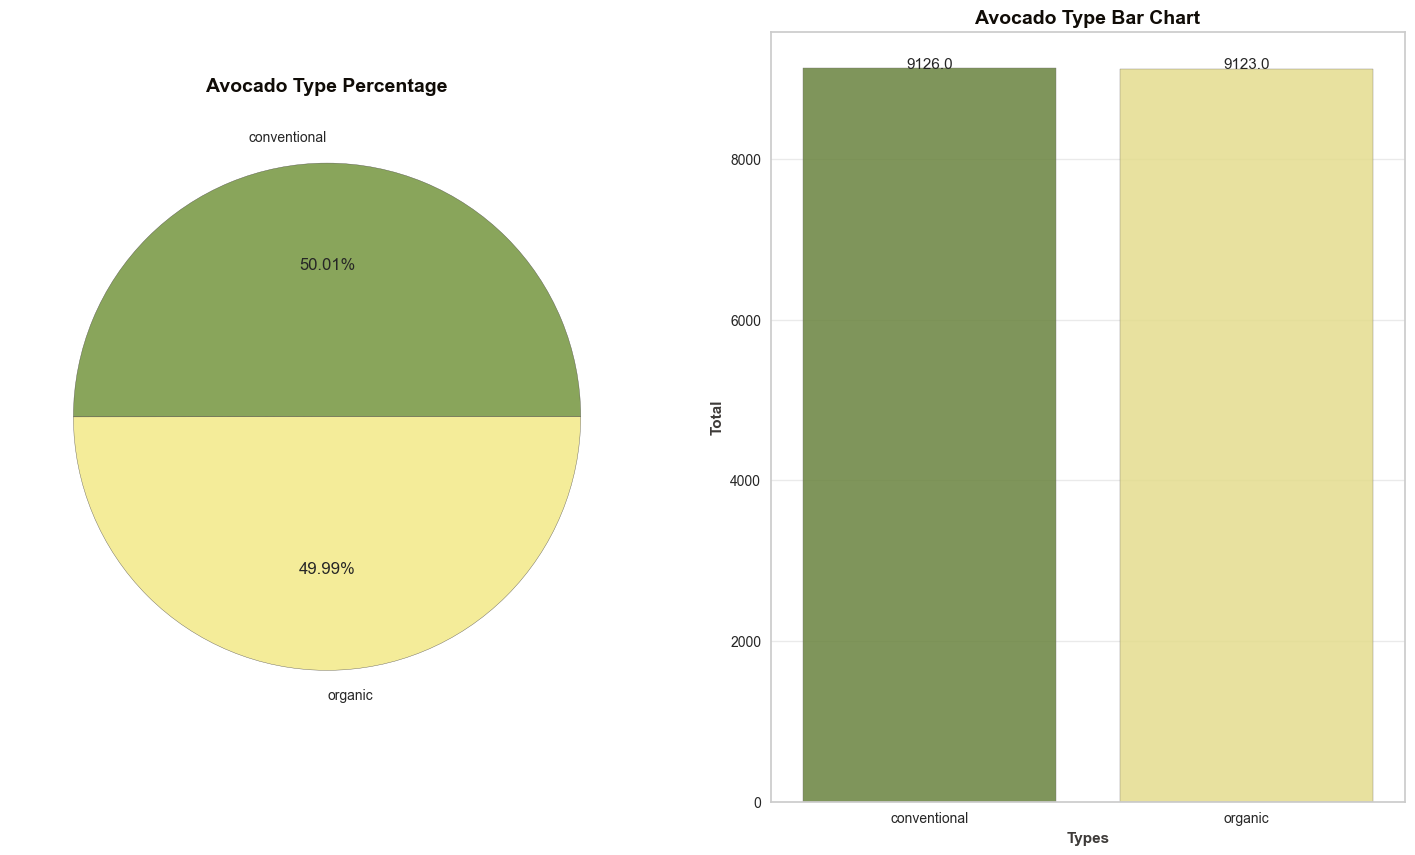

In [13]:
# 컬러 / 라벨 
colors = color_mix[1:3]
labels = ds['type'].dropna().unique()
order = ds['type'].value_counts().index

plt.figure(figsize=(18, 10))

# 파이 차트
plt.subplot(1, 2, 1)
plt.title('Avocado Type Percentage', fontweight = 'bold', 
          fontsize = 14, fontfamily = 'sans-serif', 
          color = black_grad[0])
plt.pie(ds['type'].value_counts(), labels = order, colors = colors, 
        wedgeprops = dict(alpha = 0.8, edgecolor = black_grad[1]), autopct = '%.2f%%')

# 바 차트

countplt = plt.subplot(1, 2, 2)
plt.title('Avocado Type Bar Chart', fontweight = 'bold', fontsize = 14, 
          fontfamily = 'sans-serif', color = black_grad[0])
ax = sns.countplot(x = 'type', data = ds, palette = colors, order = order,
                   edgecolor = black_grad[2], alpha = 0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2, rect.get_height()+0.75,
             rect.get_height(), horizontalalignment = 'center', fontsize = 11)

plt.xlabel('Types', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Total', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0.4)
countplt

# 라벨 카운트 
print('\033[92m'+'*' * 40)
print('\033[92m\033[1m'+'.: Total Avocado based on each Type :.'+'\033[0m')
print('\033[92m'+'*' * 40+'\033[0m')
ds.type.value_counts(dropna=False)

➡️ 비슷한분포를 보임


- Year

***********************************
.: Total Avocado based on Year :.
***********************************


year
2017    5722
2016    5616
2015    5615
2018    1296
Name: count, dtype: int64

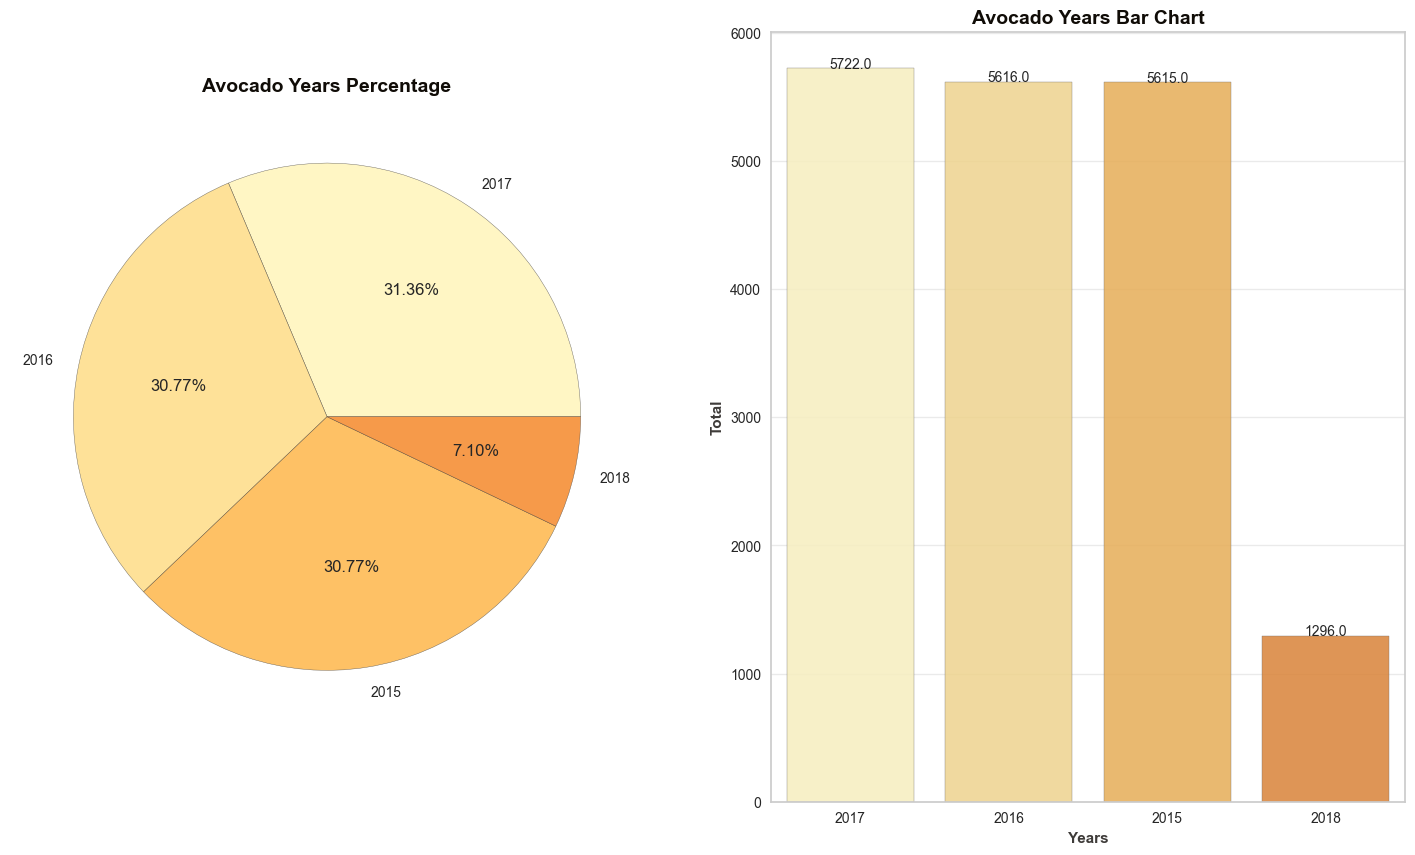

In [16]:
colors = sns.color_palette('YlOrBr')
labels = ds['year'].dropna().unique()
order = ds['year'].value_counts().index

plt.figure(figsize=(18,10))

# 파이 차트
plt.subplot(1,2,1)
plt.title('Avocado Years Percentage', fontweight = 'bold', fontsize = 14, 
          fontfamily = 'sans-serif', color = black_grad[0])
plt.pie(ds['year'].value_counts(), labels = order, colors = colors, 
        wedgeprops = dict(alpha = 0.8, edgecolor = black_grad[1]), autopct = '%.2f%%')

# 바 차트
countplt = plt.subplot(1,2,2)
plt.title('Avocado Years Bar Chart', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif', color = black_grad[0])
ax = sns.countplot(x = 'year', data = ds, palette = colors, order = order, 
                   edgecolor = black_grad[2], alpha = 0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2, rect.get_height()+0.75,
             rect.get_height(), horizontalalignment = 'center',fontsize = 10)

plt.xlabel('Years', fontweight = 'bold', fontsize = '11', fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Total', fontweight = 'bold', fontsize = '11', fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0.4)
countplt

print('\033[92m'+'*' * 35)
print('\033[92m\033[1m'+'.: Total Avocado based on Year :.'+'\033[0m')
print('\033[92m'+'*' * 35+'\033[0m')
ds.year.value_counts(dropna=False)

➡️ 2017년이 가장 높고 2018년이 가장 낮다

- Region

In [19]:
print('\033[92m'+'*' * 38)
print('\033[92m\033[1m'+'.: Total Avocado based on Regions :.'+'\033[0m')
print('\033[92m'+'*' * 38)
ds.region.value_counts(dropna=False)

**************************************
.: Total Avocado based on Regions :.
**************************************


region
Albany                 338
Sacramento             338
Northeast              338
NorthernNewEngland     338
Orlando                338
Philadelphia           338
PhoenixTucson          338
Pittsburgh             338
Plains                 338
Portland               338
RaleighGreensboro      338
RichmondNorfolk        338
Roanoke                338
SanDiego               338
Atlanta                338
SanFrancisco           338
Seattle                338
SouthCarolina          338
SouthCentral           338
Southeast              338
Spokane                338
StLouis                338
Syracuse               338
Tampa                  338
TotalUS                338
West                   338
NewYork                338
NewOrleansMobile       338
Nashville              338
Midsouth               338
BaltimoreWashington    338
Boise                  338
Boston                 338
BuffaloRochester       338
California             338
Charlotte              338
Chicago              

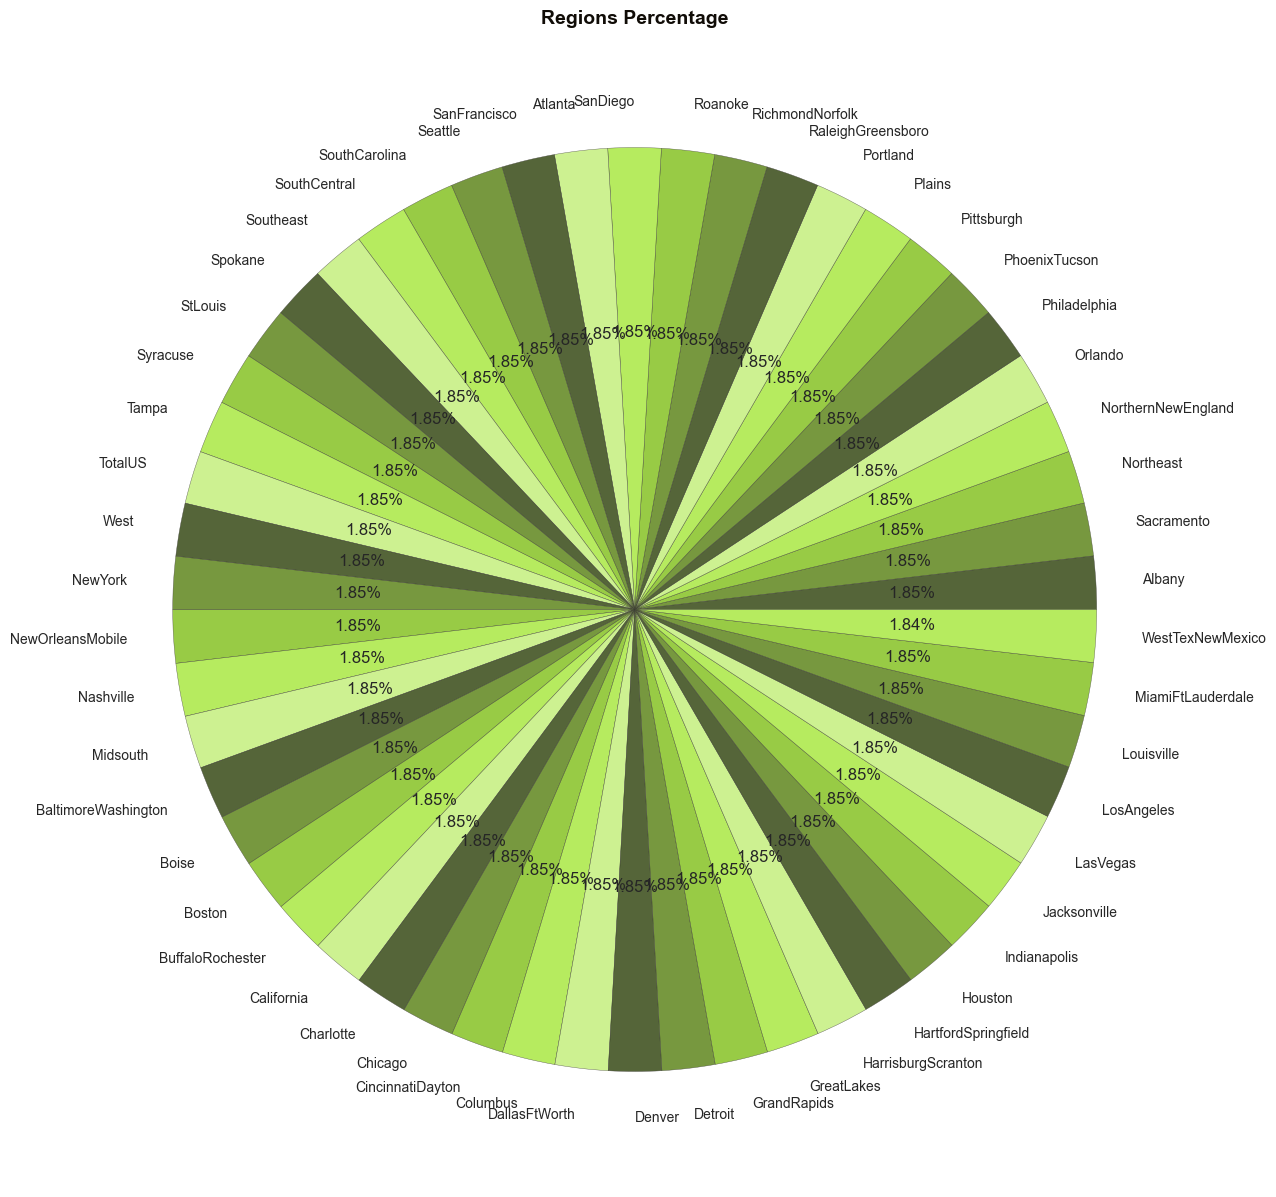

In [21]:
colors = olive_grad[0:5]
labels = ds['region'].dropna().unique()
order = ds['region'].value_counts().index

# 파이 차트
plt.figure(figsize = (15, 15))
plt.title('Regions Percentage', fontweight = 'bold', fontsize = 14, 
          fontfamily = 'sans-serif', color = black_grad[0])
plt.pie(ds['region'].value_counts(), labels = order, colors = colors, 
        wedgeprops = dict(alpha = 0.8, edgecolor = black_grad[1]), autopct = '%.2f%%');

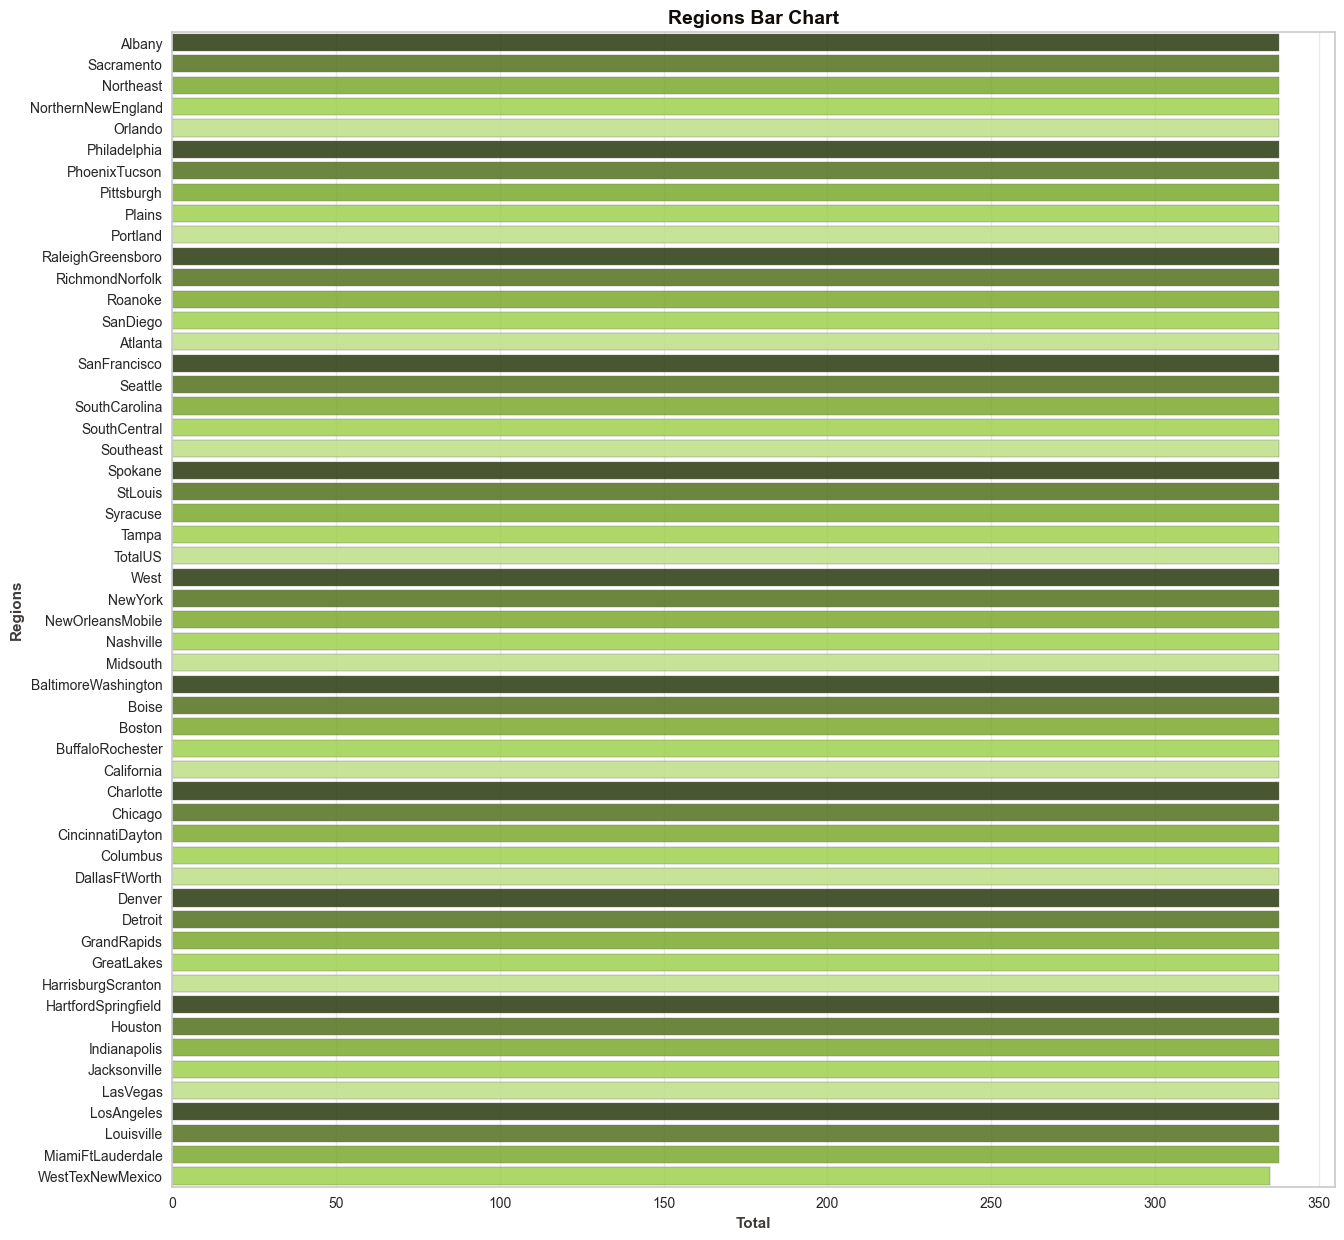

In [23]:
# 바 차트
plt.figure(figsize = (15, 15))
plt.title('Regions Bar Chart', fontweight = 'bold', fontsize = 14, 
          fontfamily = 'sans-serif', color = black_grad[0])
sns.countplot(y = 'region', data = ds, order = order, palette = colors, 
              edgecolor = black_grad[2], alpha = 0.85)
plt.xlabel('Total', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Regions', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'x', alpha = 0.4);

➡️ 비슷한 분포를 보이고 있으나, WestTexNewMexico에서는 살짝 낮음

**🥑 데이터 탐색 - Numerical Variable**

In [28]:
ds[['AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 
    'XLarge Bags']].describe().T.style.background_gradient(cmap='YlOrBr').set_properties(**{'font-family': 'Segoe UI'})

,count,mean,std,min,25%,50%,75%,max
AveragePrice,18249.000000,1.405978,0.402677,0.440000,1.100000,1.370000,1.660000,3.250000
Total Volume,18249.000000,850644.013009,3453545.355399,84.560000,10838.580000,107376.760000,432962.290000,62505646.520000
4046,18249.000000,293008.424531,1264989.081763,0.000000,854.070000,8645.300000,111020.200000,22743616.170000
4225,18249.000000,295154.568356,1204120.401135,0.000000,3008.780000,29061.020000,150206.860000,20470572.610000
4770,18249.000000,22839.735993,107464.068435,0.000000,0.000000,184.990000,6243.420000,2546439.110000
Total Bags,18249.000000,239639.202060,986242.399216,0.000000,5088.640000,39743.830000,110783.370000,19373134.370000
Small Bags,18249.000000,182194.686696,746178.514962,0.000000,2849.420000,26362.820000,83337.670000,13384586.800000
Large Bags,18249.000000,54338.088145,243965.964547,0.000000,127.470000,2647.710000,22029.250000,5719096.610000
XLarge Bags,18249.000000,3106.426507,17692.894652,0.000000,0.000000,0.000000,132.500000,551693.650000


➡️ 평균 가격에서의 분산이 낮음 / 다른 칼럼들은 더 많은 변동성을 보임



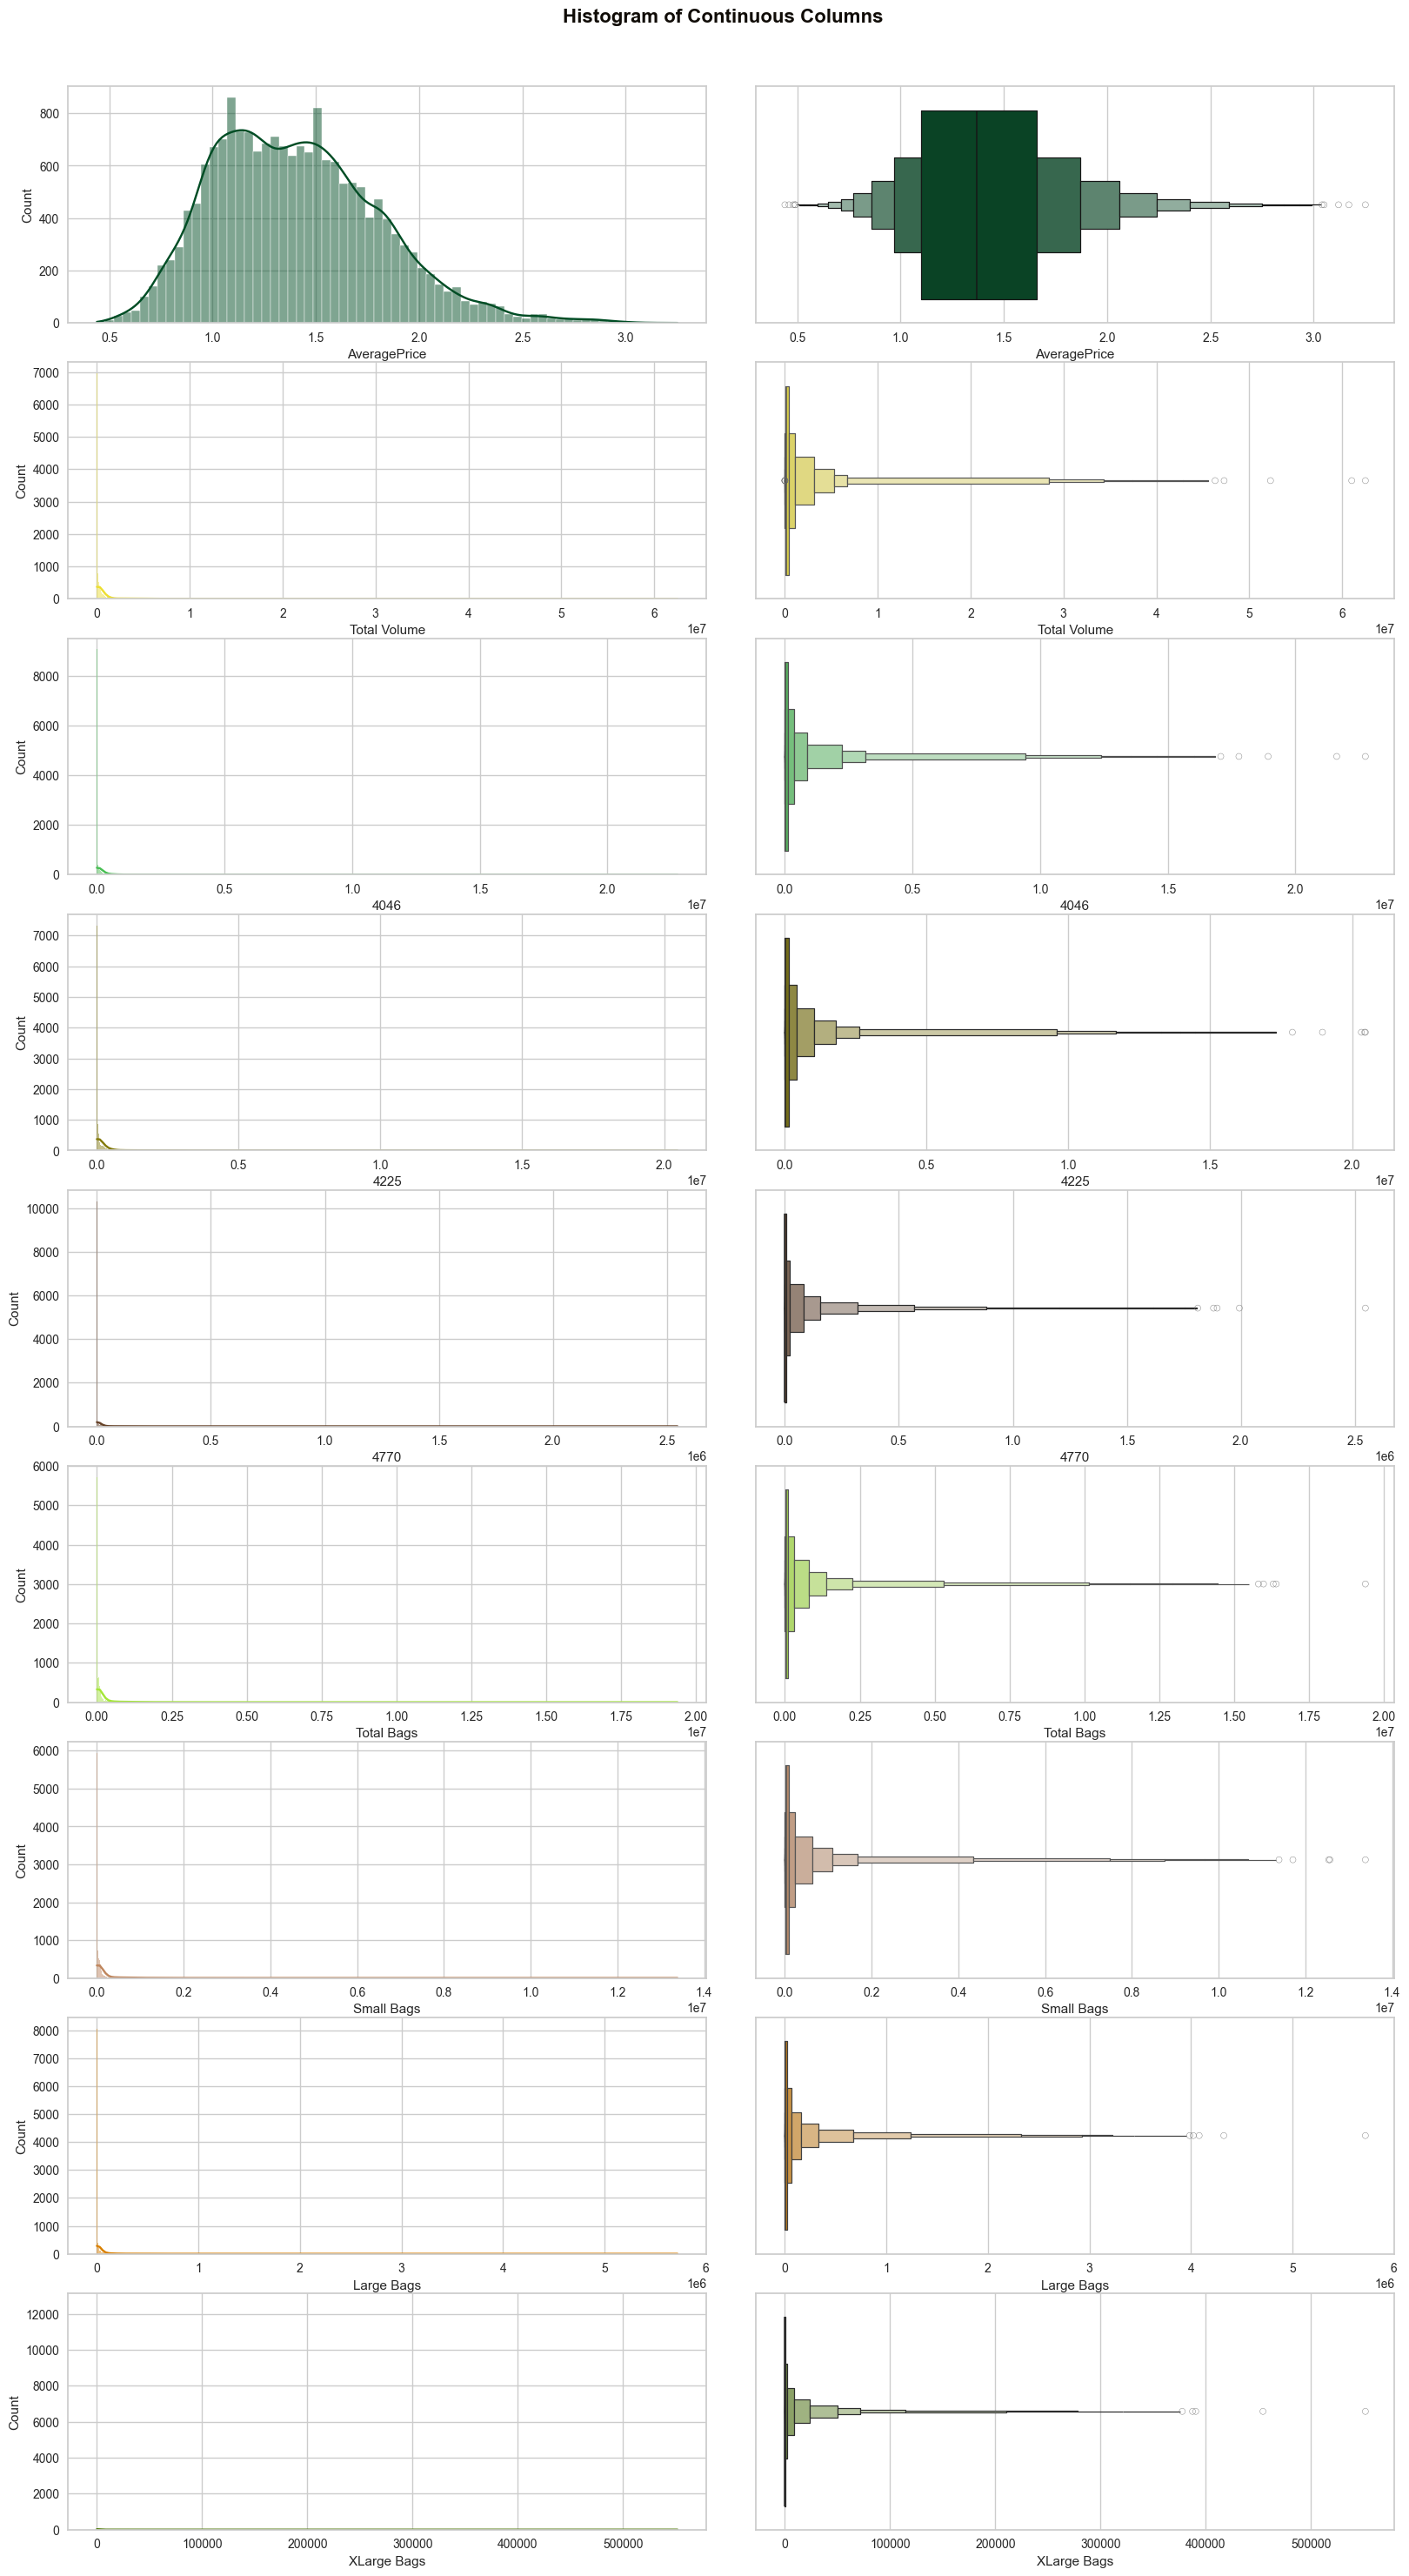

In [33]:
fig, axs = plt.subplots(9, 2, figsize = (16, 30))

fig.tight_layout()
fig.subplots_adjust(top = 0.95)
fig.suptitle('Histogram of Continuous Columns', fontweight = 'bold', fontsize = 16, 
             fontfamily = 'sans-serif', color = black_grad[0])

# row 1
sns.histplot(data = ds, x = 'AveragePrice', kde = True, ax = axs[0, 0], color = '#004D25')
sns.boxenplot(data = ds, x = 'AveragePrice', ax = axs[0, 1], color = '#004D25')

# row 2
sns.histplot(data = ds, x = 'Total Volume', kde = True, ax = axs[1, 0], color = '#EDDE30')
sns.boxenplot(data = ds, x = 'Total Volume', ax = axs[1, 1], color = '#EDDE30')

# row 3
sns.histplot(data = ds, x='4046', kde = True, ax = axs[2, 0], color = '#48BF53')
sns.boxenplot(data = ds, x = '4046', ax = axs[2, 1], color = '#48BF53')

# row 4
sns.histplot(data = ds, x = '4225', kde = True, ax = axs[3, 0], color = '#837A0B')
sns.boxenplot(data = ds, x = '4225', ax = axs[3, 1], color = '#837A0B')

# row 5
sns.histplot(data = ds, x = '4770', kde = True, ax = axs[4, 0], color = '#664228')
sns.boxenplot(data = ds, x = '4770', ax = axs[4, 1], color = '#664228')

# row 6
sns.histplot(data = ds, x = 'Total Bags', kde = True, ax = axs[5, 0], color = '#A4E637')
sns.boxenplot(data = ds, x = 'Total Bags', ax = axs[5, 1], color = '#A4E637')

# row 7
sns.histplot(data = ds, x = 'Small Bags', kde = True, ax = axs[6, 0], color = '#BF865D')
sns.boxenplot(data = ds, x = 'Small Bags', ax = axs[6, 1], color = '#BF865D')

# row 8
sns.histplot(data = ds, x = 'Large Bags', kde = True, ax = axs[7, 0], color = '#D98000')
sns.boxenplot(data = ds, x = 'Large Bags', ax = axs[7, 1], color = '#D98000')

# row 9
sns.histplot(data = ds, x = 'XLarge Bags', kde = True, ax = axs[8, 0], color = '#557F0F')
sns.boxenplot(data = ds, x = 'XLarge Bags', ax = axs[8, 1], color = '#557F0F');

➡️ 대부분의 칼럼값이 right-skewed / 평균값에서는 살짝 rigth skewed, outlier 존재 

In [35]:
print('\033[92m\033[1m'+'.: Continuous Columns Skewness :.'+'\033[0m')
print('\033[92m*' * 34+'\033[0m')
ds[['AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 
    'XLarge Bags']].skew(axis = 0, skipna = True)

.: Continuous Columns Skewness :.
**********************************


AveragePrice     0.580303
Total Volume     9.007687
4046             8.648220
4225             8.942466
4770            10.159396
Total Bags       9.756072
Small Bags       9.540660
Large Bags       9.796455
XLarge Bags     13.139751
dtype: float64

➡️ 평균값을 제외한 모든 칼럼에서의 skewness가 1이 넘음 

In [39]:
print('\033[92m\033[1m'+'.: Continuous Columns Kurtosis :.'+'\033[0m')
print('\033[92m*' * 34+'\033[0m')
ds[['AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 
    'XLarge Bags']].kurt(axis = 0, skipna = True)

.: Continuous Columns Kurtosis :.
**********************************


AveragePrice      0.325196
Total Volume     92.104458
4046             86.809113
4225             91.949022
4770            132.563441
Total Bags      112.272156
Small Bags      107.012885
Large Bags      117.999481
XLarge Bags     233.602612
dtype: float64

➡️ 평균 가격을 제외한 모든 열이 leplokurtic임 

☑️ 첨도(Kurtosis) : 분포의 꼬리의 두꺼운 정도를 나타냄

- 정규분포 첨도 (mesokurtotic) = 3
- 첨도 값이 3보다 크면 - leptokuritc
- 3보다 작으면 - platikurtic (평평)

**🥑 EDA**

- Top 5 Regions with the Most Sold

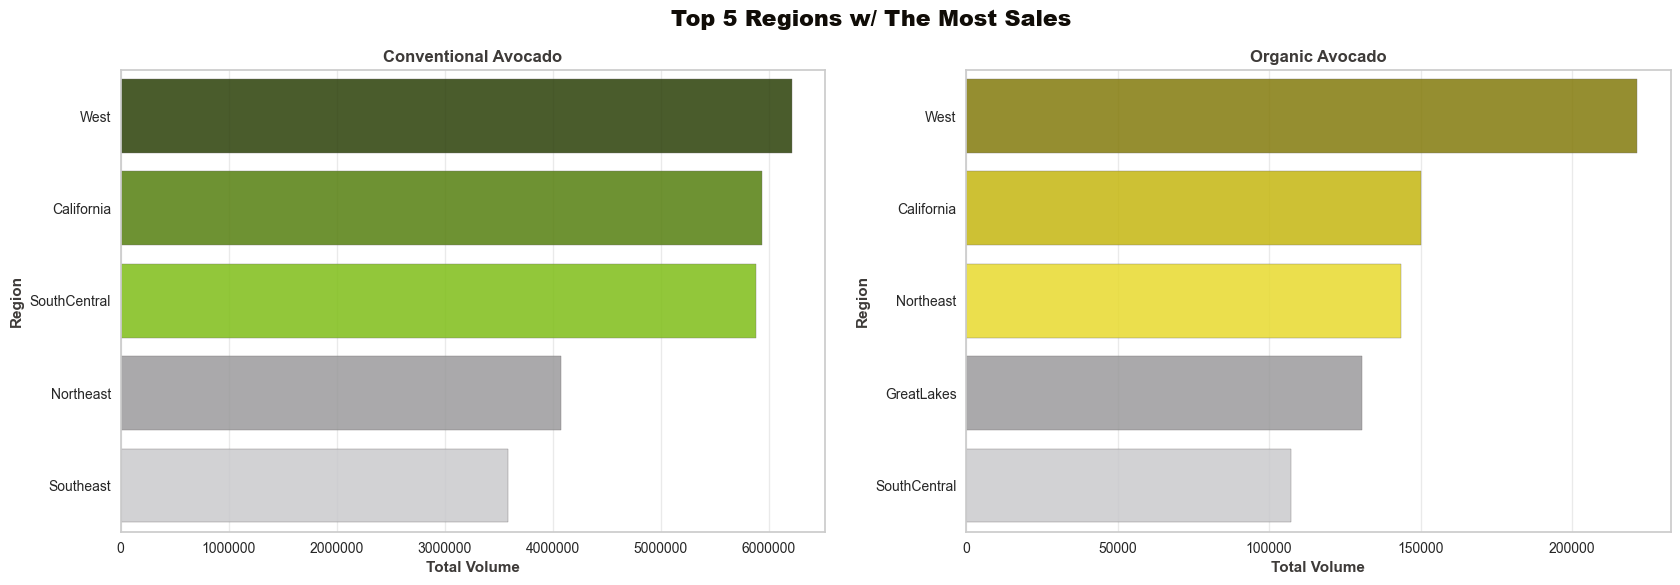

In [50]:
# df 생성
eda0 = ds[['region', 'Total Volume']][ds.type == 'conventional']
eda0 = eda0[eda0['region'] != 'TotalUS']
eda0 = eda0.groupby(['region']).aggregate({'Total Volume': np.mean}).sort_values(by = 'Total Volume', ascending = False).iloc[:5]

eda1 = ds[['region', 'Total Volume']][ds.type == 'organic']
eda1 = eda1[eda1['region'] != 'TotalUS']
eda1 = eda1.groupby(['region']).aggregate({'Total Volume': np.mean}).sort_values(by = 'Total Volume',  ascending = False).iloc[:5]


fig, ax = plt.subplots(1, 2, figsize = (20, 6))
fig.suptitle('Top 5 Regions w/ The Most Sales', fontweight = 'heavy', fontsize = 16, fontfamily = 'sans-serif',
             color = black_grad[0])

# bar chart
plt.subplot(1, 2, 1)
plt.title('Conventional Avocado', fontweight = 'bold', fontsize = 12, fontfamily = 'sans-serif', color = black_grad[1])
bar_left = sns.barplot(x='Total Volume', y = eda0.index, data = eda0, palette = black_grad, edgecolor = black_grad[2], alpha = 0.85)
bar_left.patches[0].set_facecolor(olive_grad[0])
bar_left.patches[1].set_facecolor(olive_grad[1])
bar_left.patches[2].set_facecolor(olive_grad[2])
plt.xlabel('Total Volume', fontweight='bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Region', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0)
plt.grid(axis = 'x', alpha = 0.4)
plt.ticklabel_format(style = 'plain', axis = 'x')

plt.subplot(1, 2, 2)
plt.title('Organic Avocado', fontweight = 'bold', fontsize = 12, fontfamily = 'sans-serif', color = black_grad[1])
bar_right = sns.barplot(x='Total Volume', y = eda1.index, data = eda1, palette = black_grad, edgecolor = black_grad[2], alpha = 0.85)
bar_right.patches[0].set_facecolor(yellow_grad[1])
bar_right.patches[1].set_facecolor(yellow_grad[2])
bar_right.patches[2].set_facecolor(yellow_grad[3])
plt.xlabel('Total Volume', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Region', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0)
plt.grid(axis = 'x', alpha = 0.4)
plt.ticklabel_format(style = 'plain', axis = 'x')
plt.show();

➡️ 일반 아보카도 판매량이 유기농보다 훨씬 높음 
<br>
➡️ 서부와 캘리포니아는 두 종류의 아보카도 모두에서 판매량이 가장 높음
<br>
➡️ 남중부 지역에서는 일반 아보카도에 비해 유기농이 인기가 없음 / 반대로 북동부에서는 유기농이 더 많이 팔림 

- Top 5 Region with Highest Avocado Price

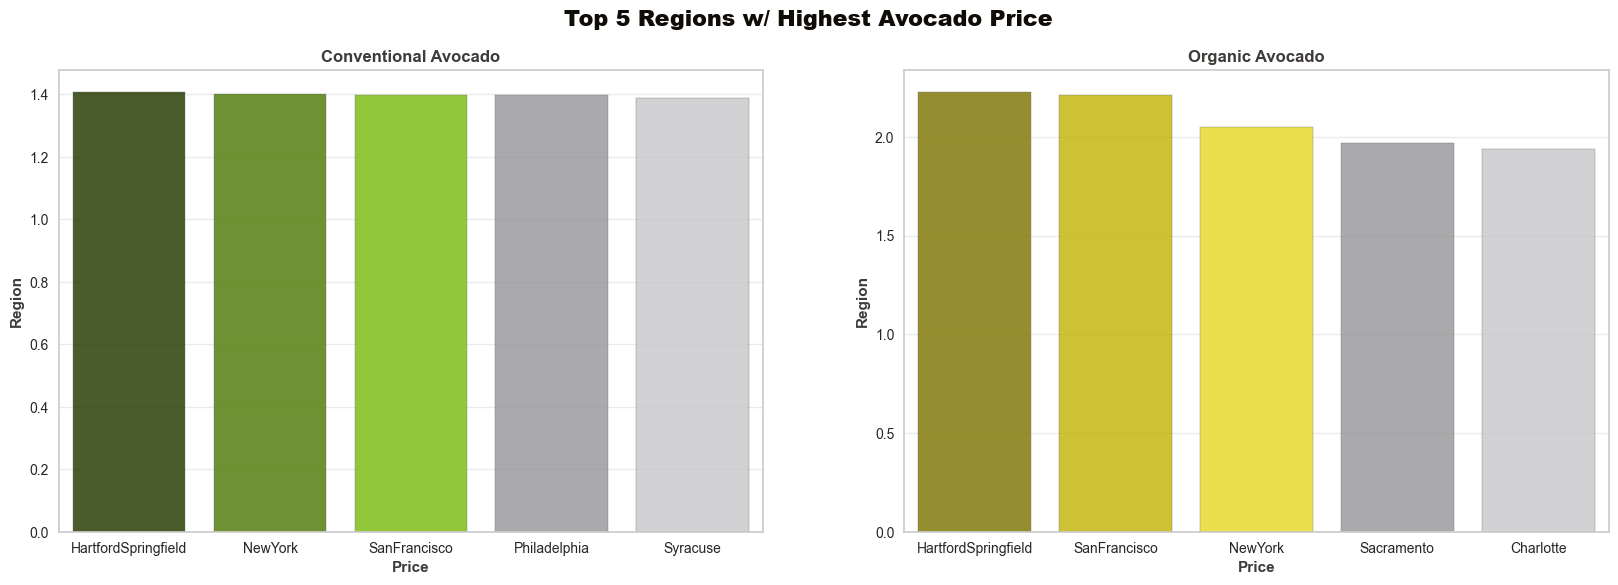

In [57]:
eda2 = ds[['region', 'AveragePrice']][ds.type == 'conventional']
eda2 = eda2.groupby(['region']).aggregate({'AveragePrice': np.mean}).sort_values(by = 'AveragePrice', ascending = False).iloc[:5]

eda3 = ds[['region', 'AveragePrice']][ds.type == 'organic']
eda3 = eda3.groupby(['region']).aggregate({'AveragePrice': np.mean}).sort_values(by = 'AveragePrice', ascending = False).iloc[:5]


fig, ax = plt.subplots(1, 2, figsize = (20, 6))
fig.suptitle('Top 5 Regions w/ Highest Avocado Price', fontweight = 'heavy', fontsize = 16, fontfamily = 'sans-serif', 
             color = black_grad[0])


plt.subplot(1, 2, 1)
plt.title('Conventional Avocado', fontweight = 'bold', fontsize = 12, fontfamily = 'sans-serif', color = black_grad[1])
bar_left = sns.barplot(y = 'AveragePrice', x = eda2.index, data = eda2, palette = black_grad, edgecolor = black_grad[2], alpha = 0.85)
bar_left.patches[0].set_facecolor(olive_grad[0])
bar_left.patches[1].set_facecolor(olive_grad[1])
bar_left.patches[2].set_facecolor(olive_grad[2])
plt.xlabel('Price', fontweight = 'bold', fontsize = '11', fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Region', fontweight = 'bold', fontsize = '11', fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0.4)
plt.grid(axis = 'x', alpha = 0)
plt.ticklabel_format(style = 'plain', axis = 'y')

plt.subplot(1, 2, 2)
plt.title('Organic Avocado', fontweight = 'bold', fontsize = '12', fontfamily = 'sans-serif', color = black_grad[1])
bar_right = sns.barplot(y='AveragePrice', x = eda3.index, data = eda3, palette = black_grad, edgecolor = black_grad[2], alpha = 0.85)
bar_right.patches[0].set_facecolor(yellow_grad[1])
bar_right.patches[1].set_facecolor(yellow_grad[2])
bar_right.patches[2].set_facecolor(yellow_grad[3])
plt.xlabel('Price', fontweight='bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Region', fontweight = 'bold', fontsize = '11', fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0.4)
plt.grid(axis = 'x', alpha = 0)
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.show();

➡️ 일반적으로 유기농보다 일반 아보카도가 더 비쌈<br>
➡️ 유기농은 지역별 가격차이가 상대적으로 크다

- Avacado PLU Sold Comparison between Avocado Types

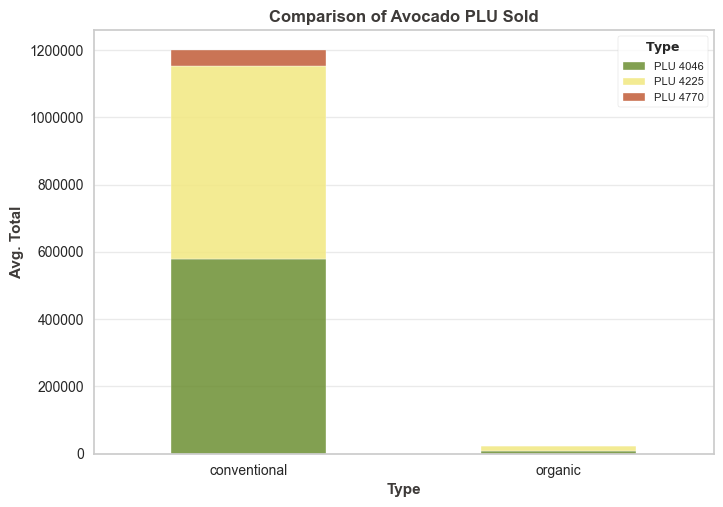

In [64]:
eda30 = ds[['type', '4046', '4225', '4770']]
eda30 = eda30.groupby(['type']).aggregate({'4046': np.mean, '4225': np.mean, '4770': np.mean})

eda30.plot(kind='bar', stacked = True, color = color_mix[-4:-1], alpha = 0.85)
plt.title('Comparison of Avocado PLU Sold', fontweight = 'bold', fontsize = '12', 
          fontfamily = 'sans-serif', color = black_grad[1])
plt.xlabel('Type', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Avg. Total', fontweight = 'bold', fontsize = '11', fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0.4)
plt.grid(axis = 'x', alpha = 0)
plt.legend(labels = ['PLU 4046','PLU 4225', 'PLU 4770'], title = '$\\bf{Type}$', 
           fontsize = '8', title_fontsize = '9', loc = 'upper right', frameon = True)
plt.xticks(rotation = 0)
plt.ticklabel_format(style = 'plain', axis = 'y')

➡️ PLU 4046과 PLU 4225를 가진 일반 아보카도는 판매량이 거의 비슷한 것으로 나타남, 반면, PLU 4770을 가진 일반 아보카도는 판매량이 매우 적음 

-  Bag Size Comparison between Avocado Types

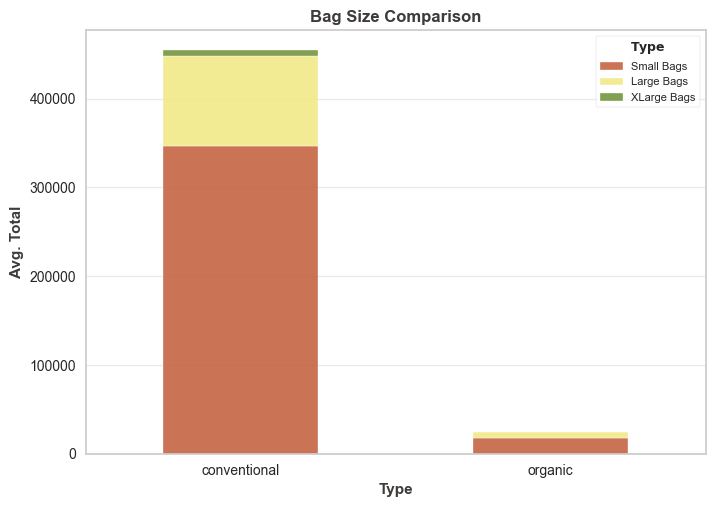

In [67]:
eda31 = ds[['type', 'Small Bags', 'Large Bags', 'XLarge Bags']]
eda31 = eda31.groupby(['type']).aggregate({'Small Bags': np.mean, 'Large Bags': np.mean, 'XLarge Bags': np.mean})

eda31.plot(kind = 'bar', stacked = True, color = color_mix[3:0:-1], alpha = 0.85)
plt.title('Bag Size Comparison', fontweight = 'bold', fontsize = 12, fontfamily = 'sans-serif', color = black_grad[1])
plt.xlabel('Type', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Avg. Total', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0.4)
plt.grid(axis = 'x', alpha = 0)
plt.legend(labels = ['Small Bags','Large Bags', 'XLarge Bags'], title = '$\\bf{Type}$', 
           fontsize = 8, title_fontsize = 9, loc = 'upper right', frameon = True)
plt.xticks(rotation = 0)
plt.ticklabel_format(style = 'plain', axis = 'y');

➡️ 두 종류 아보카도 모두 small bag 타입이 가장 많이 팔렸다 

- Average Price Distribution based on Types from 2015-2018

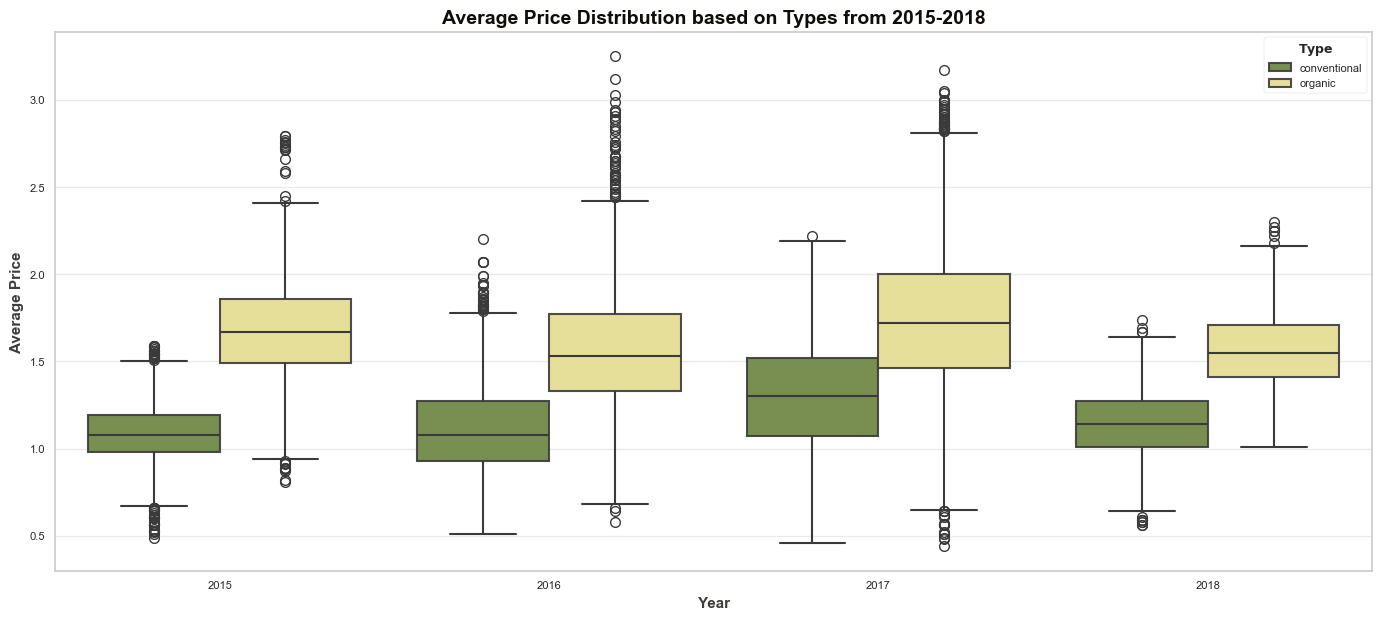

In [70]:
fig, ax = plt.subplots()
fig.set_size_inches(17, 7)
plt.title('Average Price Distribution based on Types from 2015-2018', fontweight='bold', 
          fontsize = 14, fontfamily = 'sans-serif', color = black_grad[0])
sns.boxplot(x = 'year', y = 'AveragePrice', hue = 'type', data = ds, ax = ax,
            palette = color_mix[1:3], boxprops = dict(alpha = 0.9), linewidth = 1.5)

plt.xlabel('Year', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Average Price', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.legend(title = '$\\bf{Type}$', fontsize = 8, title_fontsize = 9, loc = 'upper right', frameon = True)
plt.grid(axis = 'y', alpha = 0.4)
plt.show()

➡️ 두 아보카도 모두 2017년에 정점을 찍고 일년 후 다시 하락하는 추세를 보임 

- Scatter Plot between Total Volume and Total Bags
  <br>이분산성(Heteroscedasticity) 여부 확인하기

☑️ 이분산성이란, 잔차의 분산이 데이터 전체 범위에서 일정하지 않은 상태 (등분산성 가정 위배)

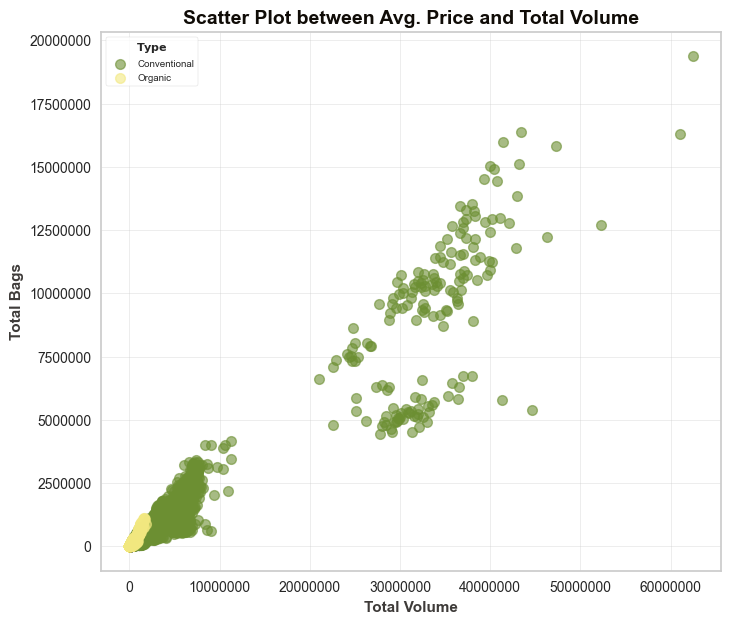

In [77]:
x0 = ds.xs('Total Volume', axis = 1)[ds.type == 'conventional']
x1 = ds.xs('Total Volume', axis = 1)[ds.type == 'organic']
y0 = ds.xs('Total Bags', axis = 1)[ds.type == 'conventional']
y1 = ds.xs('Total Bags', axis = 1)[ds.type == 'organic']

plt.figure(figsize = (8, 7))
plt.title('Scatter Plot between Avg. Price and Total Volume', fontweight = 'bold', fontsize = 14, 
          fontfamily = 'sans-serif', color = black_grad[0])
plt.scatter(x = x0, y = y0, c = color_mix[1], alpha = 0.6, linewidths = 1)
plt.scatter(x = x1, y = y1, c = color_mix[2], alpha = 0.6, linewidths = 1)
plt.legend(['Conventional', 'Organic'], title = '$\\bf{Type}$', fontsize = 7, title_fontsize = 8, loc = 'upper left',
           frameon = True)
plt.xlabel('Total Volume', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Total Bags', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ticklabel_format(style = 'plain', axis = 'both')
plt.grid(axis = 'both', alpha = 0.5, lw = 0.5)
plt.show()

➡️ 뚜렷한 이분산성을 보임. 잔차가 변수 값에 따라 증가 

-  Time Series Plot of Total Avocado Sold

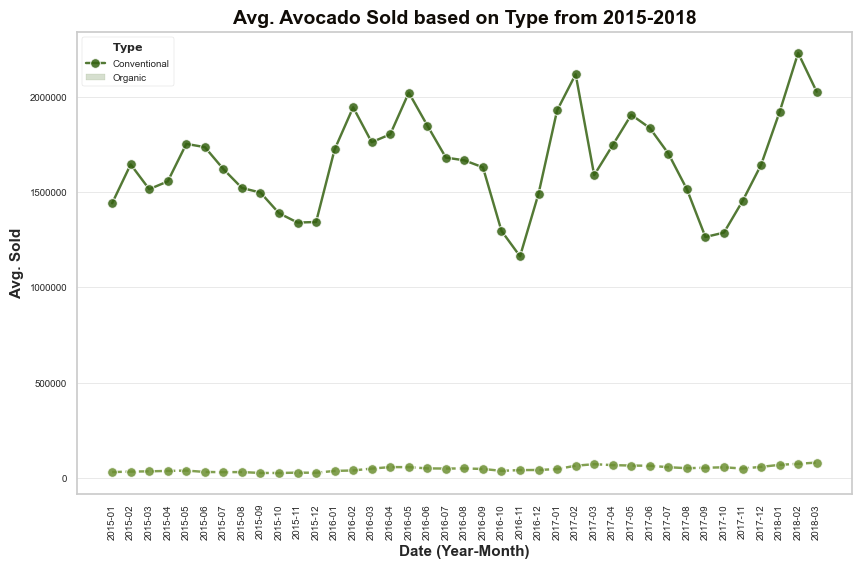

In [84]:
dseda8 = ds[['Date', 'Total Volume', 'type']]
dseda8['Date'] = pd.DatetimeIndex(dseda8['Date'])
dseda8['Date'] = dseda8['Date'].apply(lambda x: x.strftime('%Y-%m'))
group8 = dseda8.groupby(['Date', 'type'])
mnth_avg8 = group8.aggregate({'Total Volume': np.mean})

plt.figure(figsize = (10, 6))
plt.title('Avg. Avocado Sold based on Type from 2015-2018', fontweight = 'bold', fontsize = 14,
          fontfamily = 'sans-serif', color = black_grad[0])
sns.lineplot(data = mnth_avg8, x = 'Date', y = 'Total Volume', hue = 'type', style = 'type', markers = ['o', 'o'],
             palette = color_mix[0:2], alpha = 0.85)
plt.xlabel('Date (Year-Month)', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif')
plt.ylabel('Avg. Sold', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation = 'vertical', fontsize = 7)
plt.yticks(fontsize = 7)
plt.grid(axis='y', alpha = 0.5, lw = 0.6)
plt.grid(axis='x', alpha = 0)
plt.legend(labels = ['Conventional', 'Organic'], title = '$\\bf{Type}$', fontsize = 7, title_fontsize = 8, frameon=True);

➡️ 일반아보카도의 판매량이 더 높음
<br>
➡️ 2015~2018년 초까지는 판매량의 뚜렷한 감소나 증가가 없음 

- Time Series Plot of Avg. Price

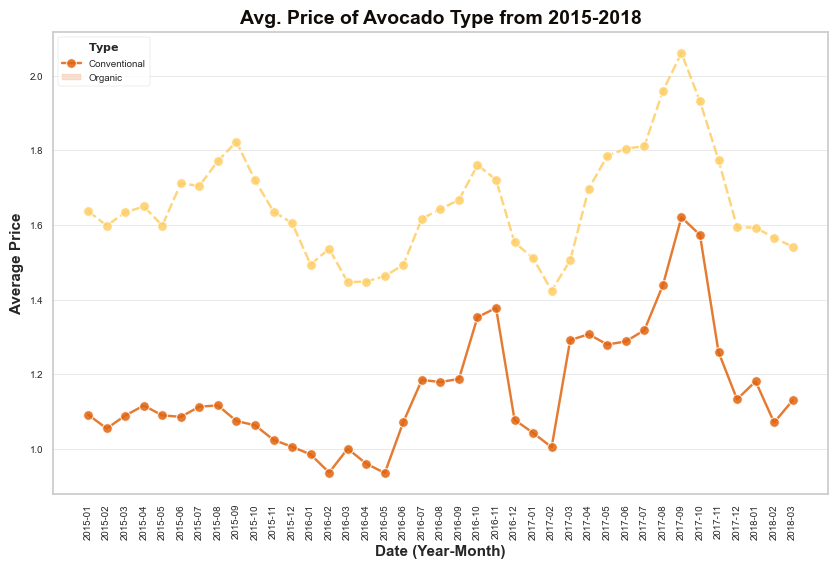

In [91]:
dseda9 = ds[['Date', 'AveragePrice', 'type']]
dseda9['Date'] = pd.DatetimeIndex(dseda9['Date'])
dseda9['Date'] = dseda9['Date'].apply(lambda x: x.strftime('%Y-%m'))
group9 = dseda9.groupby(['Date', 'type'])
mnth_avg9 = group9.aggregate({'AveragePrice': np.mean})

plt.figure(figsize = (10, 6))
plt.title('Avg. Price of Avocado Type from 2015-2018', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif',
          color = black_grad[0])
sns.lineplot(data = mnth_avg9, x = 'Date', y = 'AveragePrice', hue = 'type', style = 'type', markers = ['o', 'o'],
             palette = 'YlOrBr_r', alpha = 0.85)
plt.xlabel('Date (Year-Month)', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif')
plt.ylabel('Average Price', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif')
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.xticks(rotation = 'vertical', fontsize = 7)
plt.yticks(fontsize = 7)
plt.grid(axis = 'y', alpha = 0.5, lw = 0.6)
plt.grid(axis = 'x', alpha = 0)
plt.legend(labels = ['Conventional', 'Organic'], title = '$\\bf{Type}$', fontsize = 7, title_fontsize = 8,
           loc = 'upper left', frameon = True)

➡️ 두 종류의 아보카도 가격 변동이 유사하다 

- Heatmap

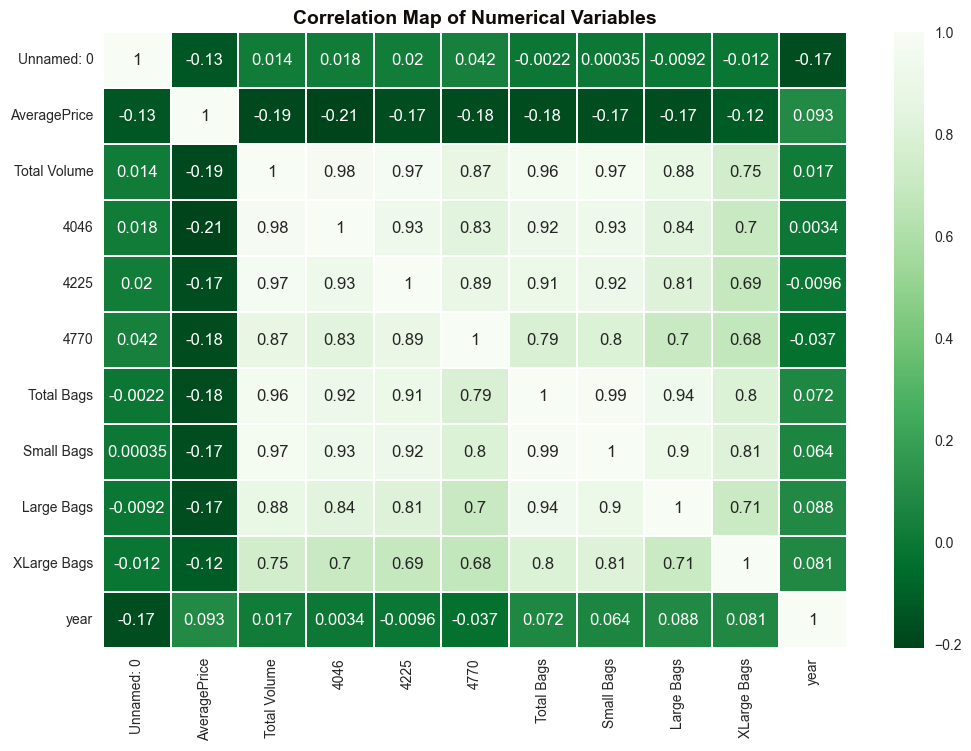

In [106]:
plt.figure(figsize = (12, 8))
numeric_cols = ds.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot = True, cmap = 'Greens_r', linewidths = 0.1)
plt.title('Correlation Map of Numerical Variables', fontsize = 14, fontweight = 'bold', fontfamily = 'sans-serif', color = black_grad[0]);

- EDA 결론
  - 일반 아보카도는 가격이 저렴하고 판매량이 가장 많으며, 가격 차이가 적다 반면 유기농 아보카도는 가격이 높고 판매량이 적으며, 가격 차이가 큼 사람들은 가격이 저렴한 일반 아보카도를 더 선호하는 경향이 있음
  - 일반 아보카도의 판매에 가장 좋은 시기는 연말에서 다음 해 2월 사이
  - 유기농 아보카도의 가격은 일반 아보카도 가격을 따르지만, 아보카도의 총 판매량에는 큰 영향을 미치지 않음
  - 서부 지역과 캘리포니아는 두 아보카도 종류 모두에서 가장 높은 판매율을 보임
  - PLU 4046과 PLU 4225의 아보카도는 PLU 4770보다 평균 판매량이 많았음 또한, 작은 아보카도 백이 다른 아보카도 백보다 평균 판매량이 높았다.
  - 전체 아보카도의 판매량이 많을수록 아보카도 백의 수도 많아지는 경향을 보임. 이는 산점도에서 이분산성으로 확인할 수 있으며, 상관 관계 맵에서 두 변수 간의 높은 상관 계수도 확인 가능.

**🥑 데이터 전처리**

In [111]:
# datetime으로 변환 
ds.Date = pd.to_datetime(ds.Date)

# 달 만 추출
ds['month'] = pd.DatetimeIndex(ds['Date']).month

**🥑 PyCaret 환경 셋업**

모듈을 설정하려면 타겟 변수, 학습 데이터 비율 등을 정의해야 함 
- 타겟 변수: 평균 가격
- 학습/테스트 데이터 비율: 8:2
- 범주형 변수 정의: (type, year, region, month)
- 이전 관측에서 이상치가 있으므로, 정규화 기법을 사용
- 분산이 낮은 특징은 무시

In [119]:
avc = setup(data = ds, target = 'AveragePrice', train_size = 0.8,
            categorical_features = ['type', 'year', 'region', 'month'], 
            normalize = True, normalize_method = 'robust', 
            session_id = 123, low_variance_threshold=0.01)

,Description,Value
0,Session id,123
1,Target,AveragePrice
2,Target type,Regression
3,Original data shape,"(18249, 15)"
4,Transformed data shape,"(18249, 31)"
5,Transformed train set shape,"(14599, 31)"
6,Transformed test set shape,"(3650, 31)"
7,Numeric features,9
8,Date features,1
9,Categorical features,4


**🥑 PyCaret Regression Models**

In [122]:
models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


**🥑 Comparing All Models**

`compare_models()` 함수는 모든 모델이 성공적으로 실행된 후 모델의 성능을 평가하는 데 사용됨. 이번 실헝에서는 R2 점수로 평가

In [126]:
best_models = compare_models(sort='R2')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.0739,0.0117,0.1081,0.9278,0.0434,0.0545,1.4320
catboost,CatBoost Regressor,0.0832,0.0130,0.1138,0.9199,0.0455,0.0608,2.5810
rf,Random Forest Regressor,0.0801,0.0132,0.1146,0.9187,0.0460,0.0592,2.8420
xgboost,Extreme Gradient Boosting,0.0843,0.0135,0.1159,0.9168,0.0463,0.0615,0.1920
lightgbm,Light Gradient Boosting Machine,0.0986,0.0174,0.1320,0.8922,0.0535,0.0731,0.2900
dt,Decision Tree Regressor,0.1115,0.0284,0.1685,0.8241,0.0673,0.0813,0.1290
gbr,Gradient Boosting Regressor,0.1380,0.0341,0.1846,0.7894,0.0740,0.1024,1.2540
knn,K Neighbors Regressor,0.1563,0.0466,0.2158,0.7122,0.0862,0.1153,0.1610
ada,AdaBoost Regressor,0.1825,0.0523,0.2285,0.6771,0.0949,0.1443,0.4520
ridge,Ridge Regression,0.1823,0.0583,0.2413,0.6401,0.0975,0.1373,0.1190


➡️ top 3 모델들
- Extra Tree Regressor (0.9278)
- catBoost (0.9199)
- Random Forest Regressor (0.9182)

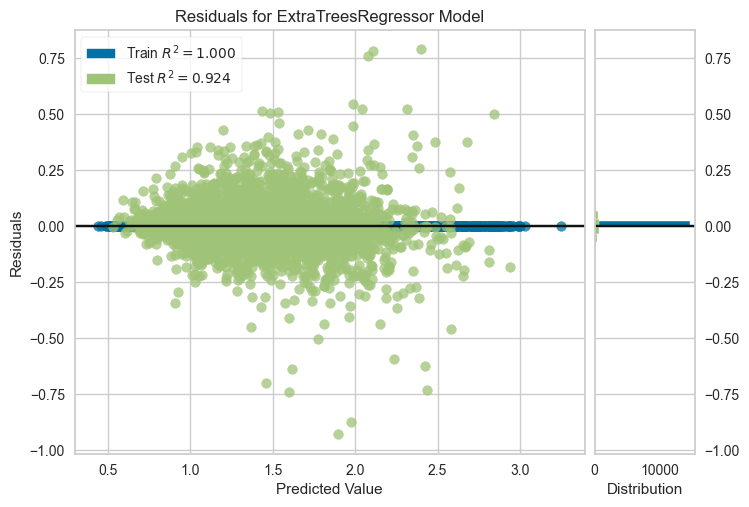

In [129]:
# best model plot 그리기 
plot_model(best_models)

➡️ 테스트 세트가 수평 축을 중심으로 무작위로 분포되어 있는 것을 볼 수 있으며, 이는 모델의 적합도가 좋다는 뜻


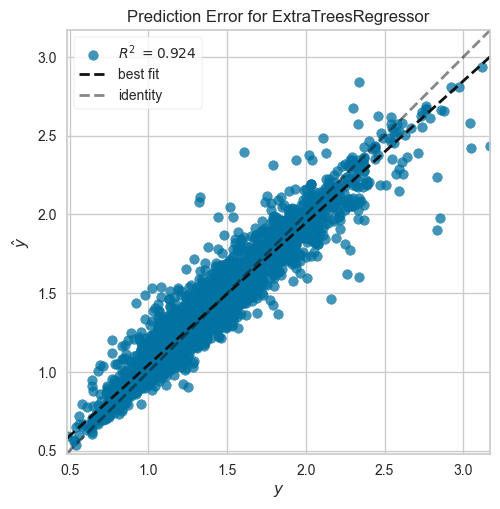

In [132]:
# y vs fitted y plot
plot_model(best_models, plot = 'error')


➡️ 예측값과 실제 값 사이 차이가 작음 -> 정확도가 매우 좋다

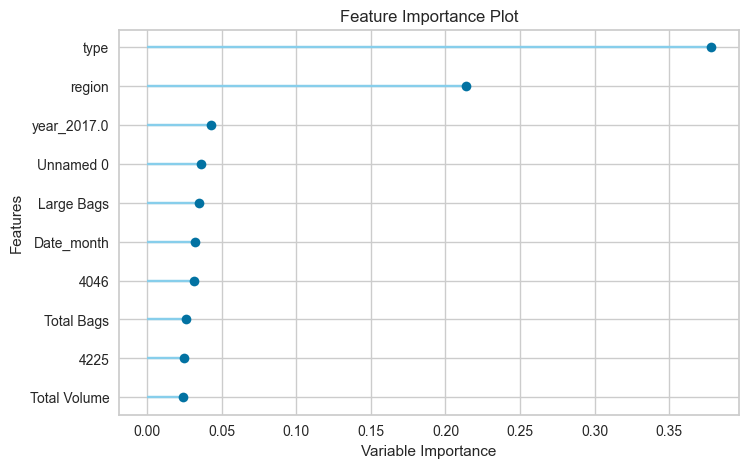

In [135]:
# 피처 중요도 plot
plot_model(best_models, plot = 'feature')

➡️ type이 가장 중요하게 작용 

In [138]:
# 베스트 모델 튜닝
tuned_best = tune_model(best_models)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1933,0.0671,0.2590,0.5994,0.1029,0.1462
1,0.2001,0.0687,0.2621,0.6020,0.1049,0.1511
2,0.1885,0.0597,0.2443,0.6041,0.1021,0.1504
3,0.1917,0.0660,0.2568,0.5991,0.1034,0.1473
4,0.1955,0.0653,0.2555,0.6013,0.1032,0.1499
5,0.1875,0.0606,0.2463,0.5996,0.1015,0.1479
6,0.1940,0.0650,0.2549,0.5947,0.1046,0.1525
7,0.1977,0.0733,0.2708,0.5678,0.1069,0.1474
8,0.1967,0.0677,0.2602,0.5709,0.1064,0.1534


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


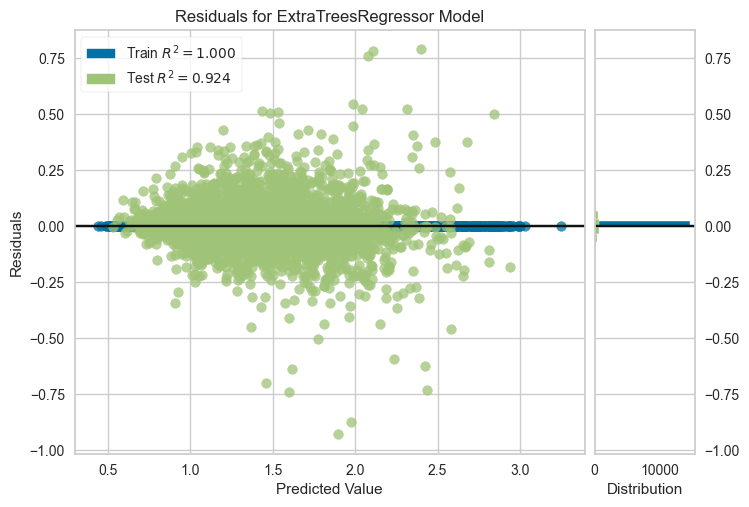

In [166]:
# 튜닝된 베스트 모델 residual plot
plot_model(tuned_best)

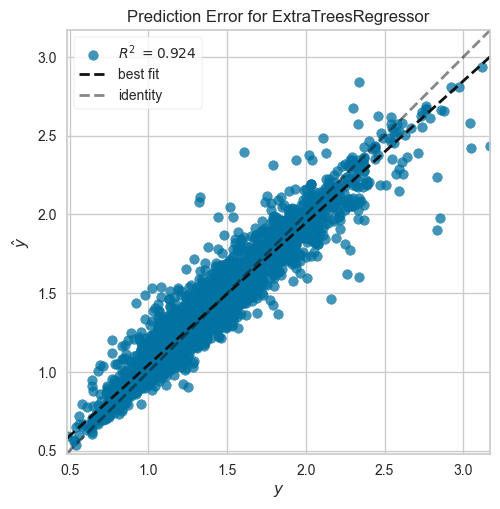

In [167]:
# y vs fitted y plot
plot_model(tuned_best, plot = 'error')

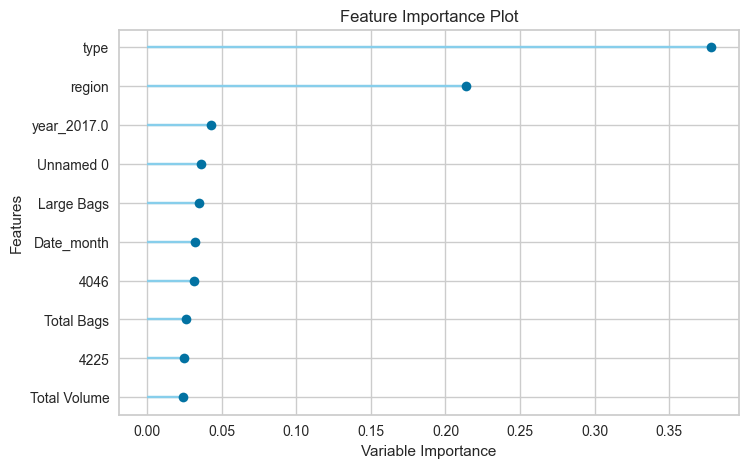

In [168]:
# 피쳐 중요도 plot
plot_model(tuned_best, plot = 'feature')

➡️ 성능이 더 떨어짐, 튜닝 실패 

**🥑 Create Model**
<br>RandomForest, LightGBM 만들어서 튜닝 진행

In [173]:
rf = create_model('rf')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0813,0.0140,0.1183,0.9164,0.0466,0.0591
1,0.0800,0.0120,0.1096,0.9304,0.0446,0.0587
2,0.0791,0.0127,0.1129,0.9155,0.0461,0.0594
3,0.0791,0.0135,0.1161,0.9180,0.0459,0.0578
4,0.0766,0.0114,0.1066,0.9306,0.0426,0.0563
5,0.0765,0.0123,0.1107,0.9191,0.0448,0.0571
6,0.0802,0.0137,0.1173,0.9142,0.0467,0.0589
7,0.0835,0.0147,0.1213,0.9133,0.0478,0.0608
8,0.0835,0.0137,0.1171,0.9131,0.0477,0.0624


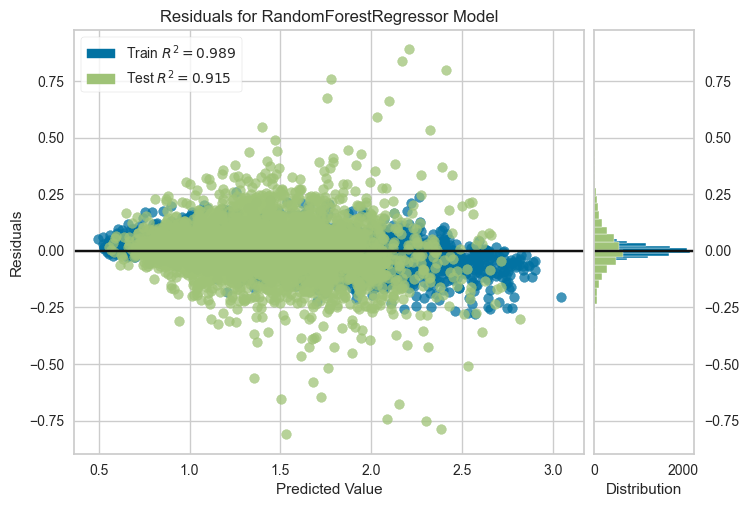

In [175]:
plot_model(rf)

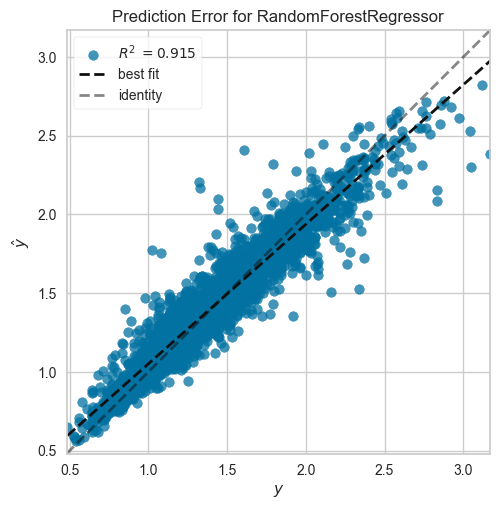

In [176]:
plot_model(rf, plot = 'error')

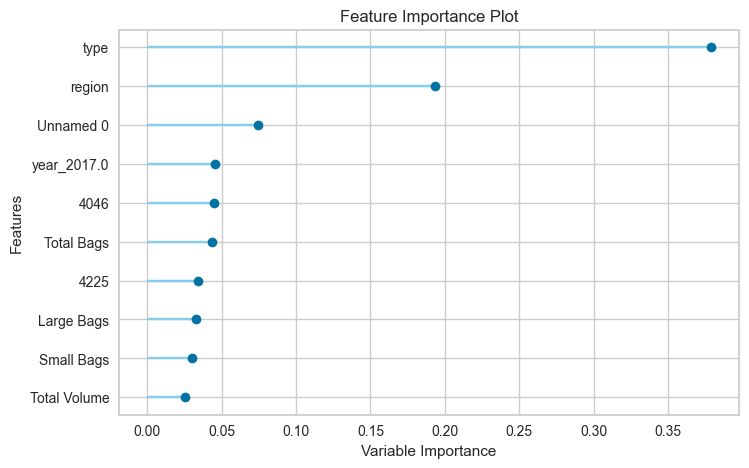

In [177]:
plot_model(rf, plot = 'feature')

- rf 튜닝하기

In [181]:
tune_rf = tune_model(rf)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1527,0.0429,0.2072,0.7436,0.0817,0.1129
1,0.1584,0.0428,0.2070,0.7519,0.0826,0.1175
2,0.1531,0.0390,0.1975,0.7413,0.0818,0.1186
3,0.1472,0.0395,0.1987,0.7600,0.0792,0.1102
4,0.1540,0.0403,0.2007,0.7539,0.0806,0.1157
5,0.1529,0.0402,0.2005,0.7347,0.0816,0.1166
6,0.1575,0.0435,0.2086,0.7285,0.0847,0.1203
7,0.1590,0.0478,0.2186,0.7185,0.0855,0.1158
8,0.1609,0.0444,0.2108,0.7183,0.0856,0.1222


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


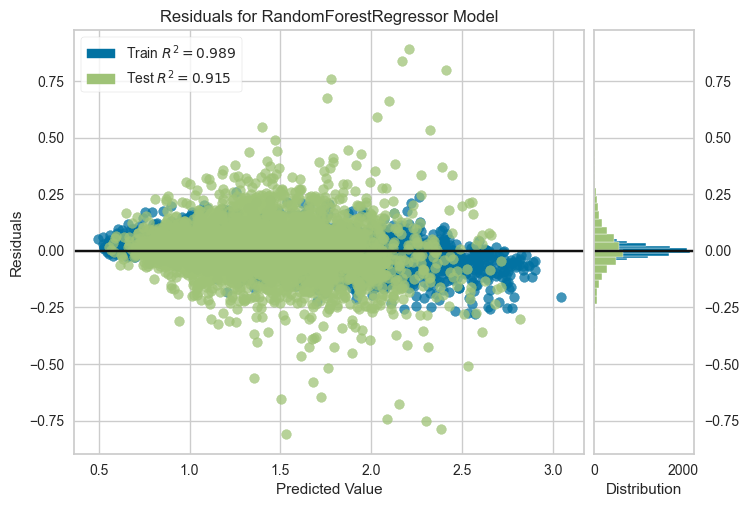

In [182]:
plot_model(tune_rf)

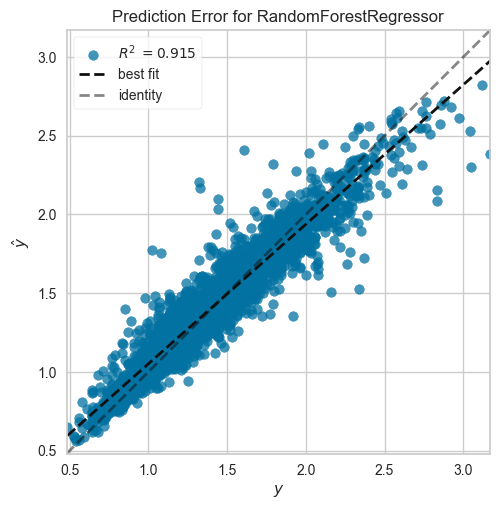

In [183]:
plot_model(tune_rf, plot = 'error')

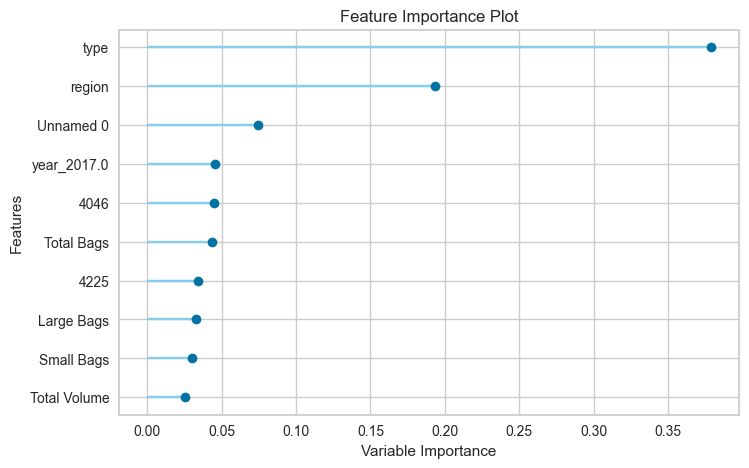

In [184]:
plot_model(tune_rf, plot = 'feature')

➡️ 성능이 더 떨어짐, 튜닝 실패 

- Light GBM

In [189]:
lgbm = create_model('lightgbm')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0988,0.0176,0.1327,0.8948,0.0528,0.0719
1,0.1005,0.0172,0.1310,0.9005,0.0531,0.0740
2,0.0990,0.0171,0.1309,0.8864,0.0542,0.0751
3,0.0943,0.0166,0.1287,0.8993,0.0516,0.0693
4,0.0936,0.0151,0.1229,0.9078,0.0495,0.0690
5,0.0966,0.0166,0.1289,0.8903,0.0526,0.0720
6,0.0989,0.0181,0.1345,0.8872,0.0541,0.0732
7,0.1024,0.0196,0.1399,0.8846,0.0557,0.0746
8,0.0994,0.0173,0.1315,0.8903,0.0541,0.0747


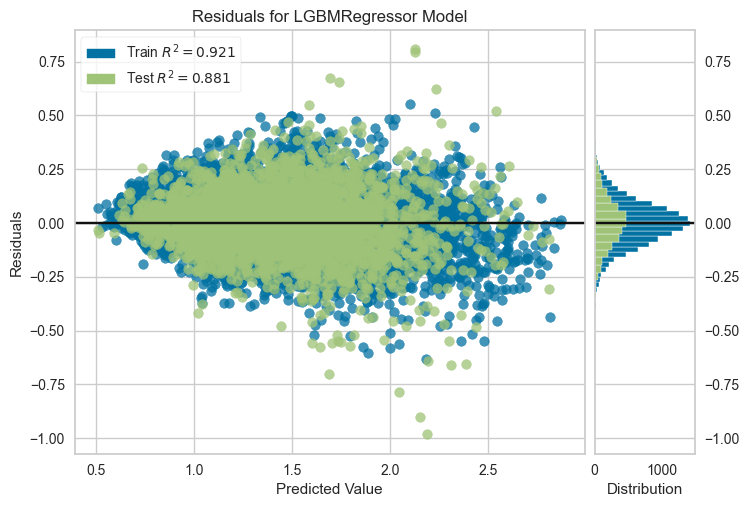

In [190]:
plot_model(lgbm)

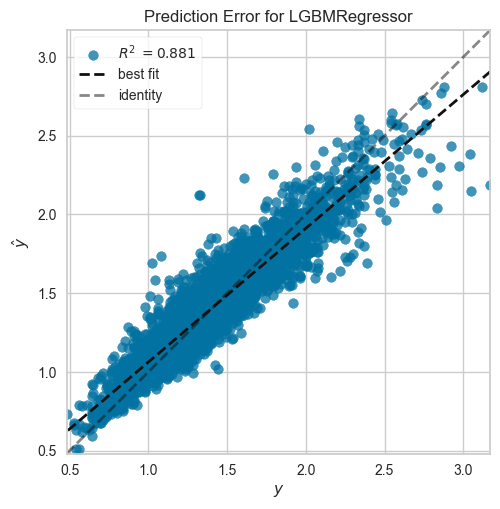

In [191]:
plot_model(lgbm, plot = 'error')

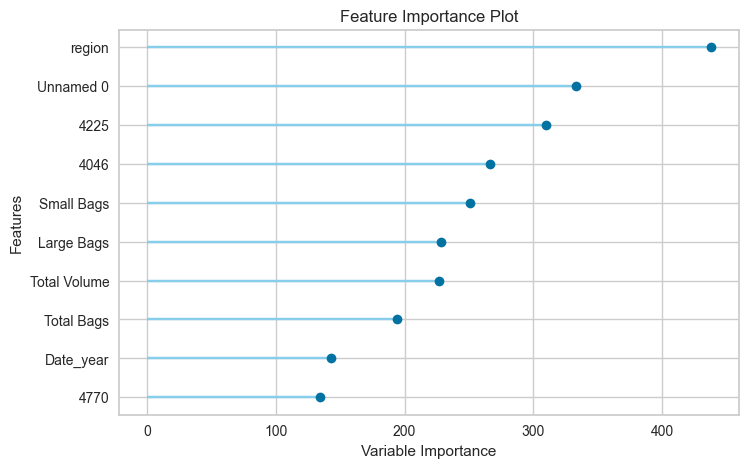

In [192]:
plot_model(lgbm, plot = 'feature')

- 튜닝하기

In [194]:
tune_lgbm = tune_model(lgbm)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1149,0.0252,0.1588,0.8495,0.0627,0.0838
1,0.1186,0.0242,0.1555,0.8599,0.0627,0.0871
2,0.1170,0.0242,0.1555,0.8397,0.0643,0.0890
3,0.1107,0.0223,0.1494,0.8643,0.0599,0.0818
4,0.1117,0.0225,0.1500,0.8625,0.0601,0.0826
5,0.1106,0.0218,0.1476,0.8562,0.0604,0.0835
6,0.1181,0.0253,0.1591,0.8420,0.0643,0.0883
7,0.1203,0.0268,0.1637,0.8421,0.0651,0.0878
8,0.1219,0.0256,0.1601,0.8375,0.0648,0.0907


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


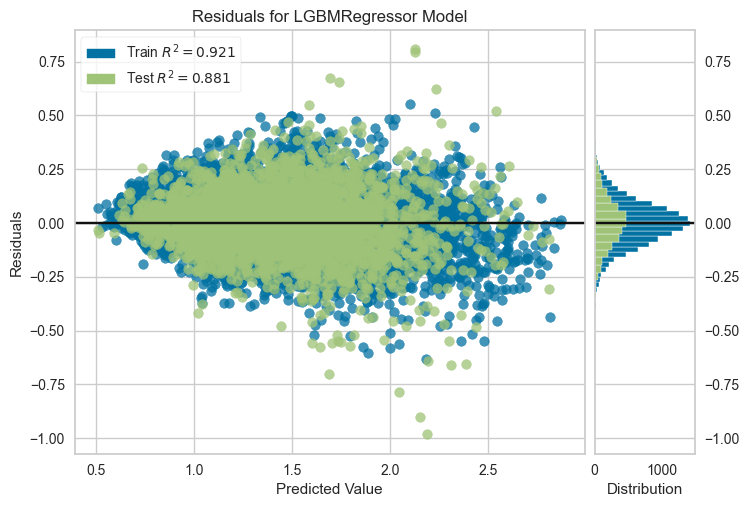

In [195]:
plot_model(tune_lgbm)

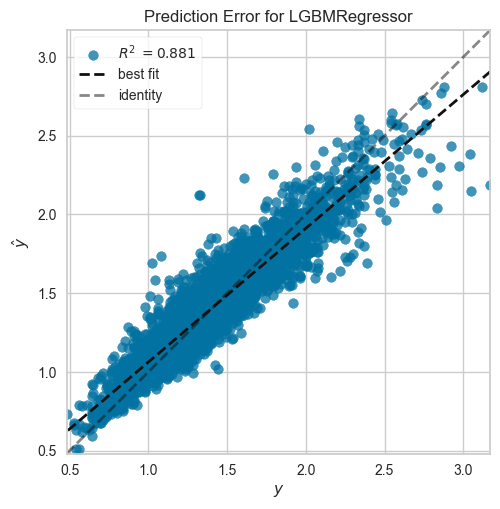

In [196]:
plot_model(tune_lgbm, plot = 'error')

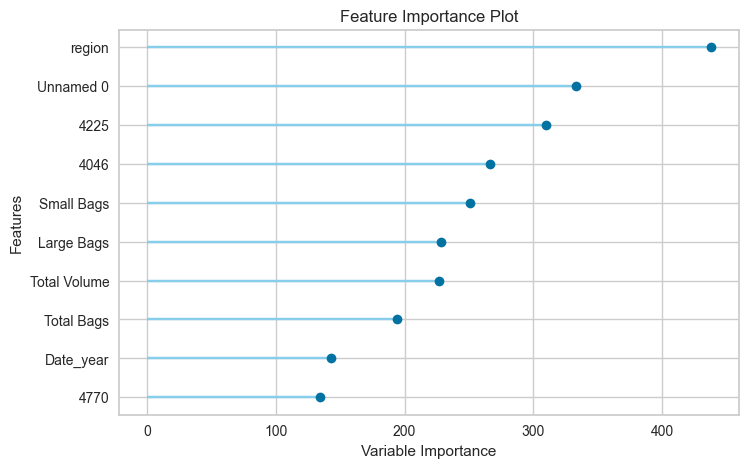

In [197]:
plot_model(tune_lgbm, plot = 'feature')

**🥑 Prediction on Test Sample**

In [203]:
predict_model(best_models)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,0.0734,0.0122,0.1106,0.9244,0.0440,0.0540


,Unnamed: 0,Date,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,month,AveragePrice,prediction_label
5078,34,2016-05-01,8.580374e+05,9.113613e+04,2.710051e+05,11463.750000,484432.531250,458041.093750,25900.730469,490.709991,conventional,2016,Seattle,5,0.82,0.8442
10697,11,2015-10-11,8.749600e+03,6.000000e+00,6.835000e+01,0.000000,8675.250000,8675.250000,0.000000,0.000000,organic,2015,NorthernNewEngland,10,1.61,1.6179
15569,33,2017-05-14,1.437912e+05,3.379520e+03,7.303243e+04,0.000000,67379.257812,29130.710938,38248.550781,0.000000,organic,2017,GreatLakes,5,1.68,1.5701
2001,25,2015-07-05,2.875719e+05,9.488031e+04,1.180226e+05,15212.240234,59456.820312,58905.710938,551.109985,0.000000,conventional,2015,RichmondNorfolk,7,1.01,1.0194
15780,32,2017-05-21,8.759490e+03,7.682000e+01,1.259860e+03,0.000000,7422.810059,2038.260010,5384.549805,0.000000,organic,2017,Indianapolis,5,0.92,1.4351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3639,51,2016-01-03,4.065584e+06,6.046972e+05,2.200075e+06,543717.875000,717093.500000,438279.968750,147920.687500,130892.796875,conventional,2016,GreatLakes,1,0.92,0.9325
326,14,2015-09-20,4.759791e+06,1.702966e+06,2.230694e+06,273922.375000,552209.750000,529779.375000,17303.910156,5126.490234,conventional,2015,California,9,1.14,1.1133
17177,51,2017-01-08,1.044249e+05,2.621250e+04,6.181320e+03,0.000000,72031.062500,69782.273438,2248.790039,0.000000,organic,2017,SouthCentral,1,1.10,1.0826
13098,21,2016-07-31,1.153139e+05,1.465426e+04,2.827826e+04,1.600000,72379.726562,70166.726562,2213.000000,0.000000,organic,2016,LosAngeles,7,1.21,1.2988


In [204]:
predict_model(rf)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,0.0798,0.0137,0.1172,0.9151,0.0466,0.0586


,Unnamed: 0,Date,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,month,AveragePrice,prediction_label
5078,34,2016-05-01,8.580374e+05,9.113613e+04,2.710051e+05,11463.750000,484432.531250,458041.093750,25900.730469,490.709991,conventional,2016,Seattle,5,0.82,0.8497
10697,11,2015-10-11,8.749600e+03,6.000000e+00,6.835000e+01,0.000000,8675.250000,8675.250000,0.000000,0.000000,organic,2015,NorthernNewEngland,10,1.61,1.6042
15569,33,2017-05-14,1.437912e+05,3.379520e+03,7.303243e+04,0.000000,67379.257812,29130.710938,38248.550781,0.000000,organic,2017,GreatLakes,5,1.68,1.5587
2001,25,2015-07-05,2.875719e+05,9.488031e+04,1.180226e+05,15212.240234,59456.820312,58905.710938,551.109985,0.000000,conventional,2015,RichmondNorfolk,7,1.01,1.0627
15780,32,2017-05-21,8.759490e+03,7.682000e+01,1.259860e+03,0.000000,7422.810059,2038.260010,5384.549805,0.000000,organic,2017,Indianapolis,5,0.92,1.2473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3639,51,2016-01-03,4.065584e+06,6.046972e+05,2.200075e+06,543717.875000,717093.500000,438279.968750,147920.687500,130892.796875,conventional,2016,GreatLakes,1,0.92,0.9434
326,14,2015-09-20,4.759791e+06,1.702966e+06,2.230694e+06,273922.375000,552209.750000,529779.375000,17303.910156,5126.490234,conventional,2015,California,9,1.14,1.0893
17177,51,2017-01-08,1.044249e+05,2.621250e+04,6.181320e+03,0.000000,72031.062500,69782.273438,2248.790039,0.000000,organic,2017,SouthCentral,1,1.10,1.1905
13098,21,2016-07-31,1.153139e+05,1.465426e+04,2.827826e+04,1.600000,72379.726562,70166.726562,2213.000000,0.000000,organic,2016,LosAngeles,7,1.21,1.3179


In [205]:
predict_model(lgbm)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,0.1018,0.0192,0.1387,0.8811,0.0552,0.0746


,Unnamed: 0,Date,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,month,AveragePrice,prediction_label
5078,34,2016-05-01,8.580374e+05,9.113613e+04,2.710051e+05,11463.750000,484432.531250,458041.093750,25900.730469,490.709991,conventional,2016,Seattle,5,0.82,0.857325
10697,11,2015-10-11,8.749600e+03,6.000000e+00,6.835000e+01,0.000000,8675.250000,8675.250000,0.000000,0.000000,organic,2015,NorthernNewEngland,10,1.61,1.562000
15569,33,2017-05-14,1.437912e+05,3.379520e+03,7.303243e+04,0.000000,67379.257812,29130.710938,38248.550781,0.000000,organic,2017,GreatLakes,5,1.68,1.477120
2001,25,2015-07-05,2.875719e+05,9.488031e+04,1.180226e+05,15212.240234,59456.820312,58905.710938,551.109985,0.000000,conventional,2015,RichmondNorfolk,7,1.01,1.057732
15780,32,2017-05-21,8.759490e+03,7.682000e+01,1.259860e+03,0.000000,7422.810059,2038.260010,5384.549805,0.000000,organic,2017,Indianapolis,5,0.92,1.232317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3639,51,2016-01-03,4.065584e+06,6.046972e+05,2.200075e+06,543717.875000,717093.500000,438279.968750,147920.687500,130892.796875,conventional,2016,GreatLakes,1,0.92,0.949554
326,14,2015-09-20,4.759791e+06,1.702966e+06,2.230694e+06,273922.375000,552209.750000,529779.375000,17303.910156,5126.490234,conventional,2015,California,9,1.14,1.059290
17177,51,2017-01-08,1.044249e+05,2.621250e+04,6.181320e+03,0.000000,72031.062500,69782.273438,2248.790039,0.000000,organic,2017,SouthCentral,1,1.10,1.124681
13098,21,2016-07-31,1.153139e+05,1.465426e+04,2.827826e+04,1.600000,72379.726562,70166.726562,2213.000000,0.000000,organic,2016,LosAngeles,7,1.21,1.481890


**🥑 Finalize Model**
<br> Extra Tree Regressor가 다른 모델 및 실험에 비해 가장 높은 정확도를 보였기 때문에, Extra Tree Regressor 모델을 최종 확정하고, 테스트 샘플에 대한 예측을 수행한 뒤, 향후 실제 적용을 위해 피클 파일로 저장

In [207]:
final_best = finalize_model(best_models)

plot_model(best_models, plot='parameter')

,Parameters
bootstrap,False
ccp_alpha,0.0
criterion,squared_error
max_depth,None
max_features,1.0
max_leaf_nodes,None
max_samples,None
min_impurity_decrease,0.0
min_samples_leaf,1
min_samples_split,2


In [208]:
predict_model(final_best)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,0.2360,0.1352,0.3677,0.1647,0.1445,0.1401


,Unnamed: 0,Date,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,month,AveragePrice,prediction_label
5078,34,2016-05-01,8.580374e+05,9.113613e+04,2.710051e+05,11463.750000,484432.531250,458041.093750,25900.730469,490.709991,conventional,2016,Seattle,5,0.82,0.8678
10697,11,2015-10-11,8.749600e+03,6.000000e+00,6.835000e+01,0.000000,8675.250000,8675.250000,0.000000,0.000000,organic,2015,NorthernNewEngland,10,1.61,1.1755
15569,33,2017-05-14,1.437912e+05,3.379520e+03,7.303243e+04,0.000000,67379.257812,29130.710938,38248.550781,0.000000,organic,2017,GreatLakes,5,1.68,1.1483
2001,25,2015-07-05,2.875719e+05,9.488031e+04,1.180226e+05,15212.240234,59456.820312,58905.710938,551.109985,0.000000,conventional,2015,RichmondNorfolk,7,1.01,1.0165
15780,32,2017-05-21,8.759490e+03,7.682000e+01,1.259860e+03,0.000000,7422.810059,2038.260010,5384.549805,0.000000,organic,2017,Indianapolis,5,0.92,1.2662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3639,51,2016-01-03,4.065584e+06,6.046972e+05,2.200075e+06,543717.875000,717093.500000,438279.968750,147920.687500,130892.796875,conventional,2016,GreatLakes,1,0.92,0.9092
326,14,2015-09-20,4.759791e+06,1.702966e+06,2.230694e+06,273922.375000,552209.750000,529779.375000,17303.910156,5126.490234,conventional,2015,California,9,1.14,1.1134
17177,51,2017-01-08,1.044249e+05,2.621250e+04,6.181320e+03,0.000000,72031.062500,69782.273438,2248.790039,0.000000,organic,2017,SouthCentral,1,1.10,0.8160
13098,21,2016-07-31,1.153139e+05,1.465426e+04,2.827826e+04,1.600000,72379.726562,70166.726562,2213.000000,0.000000,organic,2016,LosAngeles,7,1.21,1.1026


In [209]:
save_model(final_best,'Final_Best_Model_week9')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('date_feature_extractor',
                  TransformerWrapper(include=['Date'],
                                     transformer=ExtractDateTimeFeatures())),
                 ('numerical_imputer',
                  TransformerWrapper(include=['Unnamed: 0', 'Total Volume',
                                              '4046', '4225', '4770',
                                              'Total Bags', 'Small Bags',
                                              'Large Bags', 'XLarge Bags'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  Tran...
                                     transformer=TargetEncoder(cols=['region'],
                                                               handle_missing='return_nan'))),
                 ('low_variance',
                  TransformerWrapper(exclude=[],
                                     transformer=Varian